# Étape 1 — Exploration et préparation des données

Pipeline MLOps de scoring de risque de crédit — dataset Home Credit.  
Ce notebook couvre les phases 1 à 4 : exploration, nettoyage, feature engineering et préparation pour le modèle.

## Phase 1 — Découverte des données

---

### 1.1 Chargement des fichiers

**Objectif** : Charger tous les fichiers CSV et en faire un premier aperçu.

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)


DATA_PATH = '/home/bdb/Bureau/P6/Initiez-vous-au-MLOps/data/'

#### application_train.csv

In [3]:
application_train = pd.read_csv(DATA_PATH + 'application_train.csv')
print(f'Shape: {application_train.shape}')
application_train.info()

Shape: (307511, 122)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [4]:
application_train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

#### application_test.csv

In [5]:
application_test = pd.read_csv(DATA_PATH + 'application_test.csv')
print(f'Shape: {application_test.shape}')
application_test.info()

Shape: (48744, 121)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Columns: 121 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(40), object(16)
memory usage: 45.0+ MB


#### bureau.csv

In [6]:
bureau = pd.read_csv(DATA_PATH + 'bureau.csv')
print(f'Shape: {bureau.shape}')
bureau.info()

Shape: (1716428, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


#### bureau_balance.csv

In [7]:
bureau_balance = pd.read_csv(DATA_PATH + 'bureau_balance.csv')
print(f'Shape: {bureau_balance.shape}')
bureau_balance.info()

Shape: (27299925, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB


#### credit_card_balance.csv

In [8]:
credit_card_balance = pd.read_csv(DATA_PATH + 'credit_card_balance.csv')
print(f'Shape: {credit_card_balance.shape}')
credit_card_balance.info()

Shape: (3840312, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  

#### installments_payments.csv

In [9]:
installments_payments = pd.read_csv(DATA_PATH + 'installments_payments.csv')
print(f'Shape: {installments_payments.shape}')
installments_payments.info()

Shape: (13605401, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


#### POS_CASH_balance.csv

In [10]:
pos_cash_balance = pd.read_csv(DATA_PATH + 'POS_CASH_balance.csv')
print(f'Shape: {pos_cash_balance.shape}')
pos_cash_balance.info()

Shape: (10001358, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   object 
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 610.4+ MB


#### previous_application.csv

In [11]:
previous_application = pd.read_csv(DATA_PATH + 'previous_application.csv')
print(f'Shape: {previous_application.shape}')
previous_application.info()

Shape: (1670214, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT    

#### HomeCredit_columns_description.csv

In [12]:
columns_description = pd.read_csv(DATA_PATH + 'HomeCredit_columns_description.csv', encoding='latin-1')
print(f'Shape: {columns_description.shape}')
columns_description.info()

Shape: (219, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   219 non-null    int64 
 1   Table        219 non-null    object
 2   Row          219 non-null    object
 3   Description  219 non-null    object
 4   Special      86 non-null     object
dtypes: int64(1), object(4)
memory usage: 8.7+ KB


In [13]:
# Voir la description complète de TARGET dans le dictionnaire
print(columns_description[columns_description['Row'] == 'TARGET']['Description'].values[0])

Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)


#### sample_submission.csv

In [14]:
sample_submission = pd.read_csv(DATA_PATH + 'sample_submission.csv')
print(f'Shape: {sample_submission.shape}')
sample_submission.info()

Shape: (48744, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SK_ID_CURR  48744 non-null  int64  
 1   TARGET      48744 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 761.8 KB


In [15]:
# Toutes les descriptions des colonnes de application_train
app_desc = columns_description[
    columns_description['Table'] == 'application_{train|test}.csv'
][['Row', 'Description']]

print(f"Nombre de colonnes décrites : {len(app_desc)}")
display(app_desc)

Nombre de colonnes décrites : 122


,Row,Description
0,SK_ID_CURR,ID of loan in our sample
1,TARGET,Target variable (1 - client with payment diffi...
2,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving
3,CODE_GENDER,Gender of the client
4,FLAG_OWN_CAR,Flag if the client owns a car
...,...,...
117,AMT_REQ_CREDIT_BUREAU_DAY,Number of enquiries to Credit Bureau about the...
118,AMT_REQ_CREDIT_BUREAU_WEEK,Number of enquiries to Credit Bureau about the...
119,AMT_REQ_CREDIT_BUREAU_MON,Number of enquiries to Credit Bureau about the...
120,AMT_REQ_CREDIT_BUREAU_QRT,Number of enquiries to Credit Bureau about the...


### Aperçu rapide — Distribution de TARGET

Premier regard sur l'équilibre de la variable cible. L'analyse visuelle complète, avec graphique et implications, est dans la section **1.3**.

In [16]:
# Distribution de la variable cible TARGET
print("Distribution TARGET :")
print(application_train['TARGET'].value_counts())
print(f"\nDéséquilibre : {application_train['TARGET'].mean():.1%} de mauvais clients")

Distribution TARGET :
TARGET
0    282686
1     24825
Name: count, dtype: int64

Déséquilibre : 8.1% de mauvais clients


---

## Résumé — 1.1 Chargement des fichiers

| Fichier | Lignes | Colonnes | Rôle |
|---|---|---|---|
| **application_train** | 307 511 | 122 | Données d'entraînement avec TARGET |
| **application_test** | 48 744 | 121 | Données de soumission Kaggle (sans TARGET) |
| **bureau** | 1 716 428 | 17 | Historique crédits bureau |
| **bureau_balance** | 27 299 925 | 3 | Soldes mensuels crédits bureau |
| **credit_card_balance** | 3 840 312 | 23 | Soldes cartes de crédit |
| **installments_payments** | 13 605 401 | 8 | Paiements d'échéances |
| **POS_CASH_balance** | 10 001 358 | 8 | Soldes POS et cash |
| **previous_application** | 1 670 214 | 37 | Demandes précédentes de crédit |
| **sample_submission** | 48 744 | 2 | Format de soumission Kaggle |

**Décisions clés :**
- Seuls `application_train` et `application_test` servent respectivement à l'entraînement et à la prédiction.
- Les tables secondaires seront agrégées par `SK_ID_CURR` en **Phase 3**.
- `DAYS_EMPLOYED == 365 243` est une valeur sentinelle ("sans emploi") — à remplacer en **Phase 2**.

---

## Phase 1 — 1.2 Forme et types des données

### Objectif
Comparer `application_train` et `application_test` pour comprendre leurs différences structurelles, et expliquer pourquoi `application_test` **ne peut pas** être utilisé pour l'entraînement d'un modèle.

### Étape 1 — Dimensions de chaque dataset

On regarde combien de lignes (clients) et de colonnes (variables) contient chaque fichier.

In [17]:
# Dimensions de chaque dataset
print("=" * 50)
print("DIMENSIONS DES DATASETS")
print("=" * 50)
print(f"application_train : {application_train.shape[0]:>7} lignes × {application_train.shape[1]} colonnes")
print(f"application_test  : {application_test.shape[0]:>7} lignes × {application_test.shape[1]} colonnes")
print("=" * 50)

DIMENSIONS DES DATASETS
application_train :  307511 lignes × 122 colonnes
application_test  :   48744 lignes × 121 colonnes


### Étape 2 — Types de colonnes (int, float, object)

`.dtypes.value_counts()` compte combien de colonnes appartiennent à chaque type : numérique entier (`int64`), numérique décimal (`float64`), ou texte (`object`).

In [18]:
# Types de colonnes par dataset
print("=" * 50)
print("TYPES DE COLONNES — application_train")
print("=" * 50)
print(application_train.dtypes.value_counts().to_string())

print("\n" + "=" * 50)
print("TYPES DE COLONNES — application_test")
print("=" * 50)
print(application_test.dtypes.value_counts().to_string())

TYPES DE COLONNES — application_train
float64    65
int64      41
object     16

TYPES DE COLONNES — application_test
float64    65
int64      40
object     16


### Étape 3 — Comparaison des colonnes : train vs test

On cherche les colonnes présentes dans un dataset mais absentes de l'autre.
Un décalage révèle une information que l'un possède et l'autre non.

In [19]:
# Colonnes présentes dans train mais absentes dans test
cols_train_only = set(application_train.columns) - set(application_test.columns)

# Colonnes présentes dans test mais absentes dans train
cols_test_only = set(application_test.columns) - set(application_train.columns)

print("=" * 50)
print("COLONNES DANS TRAIN mais PAS dans TEST")
print("=" * 50)
print(cols_train_only if cols_train_only else "  Aucune")

print("\n" + "=" * 50)
print("COLONNES DANS TEST mais PAS dans TRAIN")
print("=" * 50)
print(cols_test_only if cols_test_only else "  Aucune")

COLONNES DANS TRAIN mais PAS dans TEST
{'TARGET'}

COLONNES DANS TEST mais PAS dans TRAIN
  Aucune


### Étape 4 — Vérification explicite de TARGET dans chaque dataset

`TARGET` est la variable que le modèle doit apprendre à prédire.
Sans elle, impossible d'entraîner : on ne saurait pas quoi prédire !

In [20]:
# Vérification de la présence de TARGET dans chaque dataset
def check_target(df, name):
    if 'TARGET' in df.columns:
        n_vals = df['TARGET'].notna().sum()
        print(f"  ✓ TARGET présente dans {name} — {n_vals} valeurs non-nulles")
    else:
        print(f"  ✗ TARGET ABSENTE dans {name}")

print("=" * 50)
print("PRÉSENCE DE LA VARIABLE TARGET")
print("=" * 50)
check_target(application_train, "application_train")
check_target(application_test,  "application_test")
print("=" * 50)

PRÉSENCE DE LA VARIABLE TARGET
  ✓ TARGET présente dans application_train — 307511 valeurs non-nulles
  ✗ TARGET ABSENTE dans application_test


---

## Résumé — 1.2 Forme et types des données

| Caractéristique | `application_train` | `application_test` |
|---|---|---|
| Lignes (clients) | 307 511 | 48 744 |
| Colonnes | 122 | 121 |
| float64 | 65 | 65 |
| int64 | 41 | 40 |
| object (texte) | 16 | 16 |
| Colonne TARGET | **OUI** ✓ | **NON** ✗ |

### Pourquoi application_test est inutilisable pour l'entraînement ?

`application_test` est un fichier de **compétition Kaggle** : il contient les données de clients dont on veut prédire le risque, mais **sans la réponse** (`TARGET` absente).

Un algorithme de machine learning supervisé apprend en observant des exemples **avec** leur étiquette correcte (`TARGET = 0` ou `1`). Sans cette étiquette, le modèle n'a rien à apprendre.

**Conséquence pratique :**
- `application_train` → sert à **entraîner et évaluer** le modèle (on connaît le résultat réel)
- `application_test` → sert uniquement à **produire des prédictions** à soumettre sur Kaggle (on ne connaît pas le résultat réel)

> La seule différence structurelle entre les deux fichiers est l'absence de `TARGET` dans le test : **1 colonne manquante**, mais c'est précisément celle qui rend l'entraînement possible.

---

## Phase 1 — 1.3 La variable cible (TARGET)

### Objectif
Comprendre la **distribution de TARGET** : combien de bons clients (0) vs mauvais clients (1), et ce que ce déséquilibre implique pour le modèle.

### Étape 1 — Distribution de TARGET en chiffres

On compte le nombre de clients par classe et on calcule les pourcentages.

In [21]:
# Distribution de TARGET : effectifs et pourcentages
counts = application_train['TARGET'].value_counts().sort_index()
pcts   = application_train['TARGET'].value_counts(normalize=True).sort_index() * 100

print("=" * 50)
print("DISTRIBUTION DE LA VARIABLE TARGET")
print("=" * 50)
print(f"  0 — Bon client    : {counts[0]:>7}  ({pcts[0]:.1f} %)")
print(f"  1 — Mauvais client: {counts[1]:>7}  ({pcts[1]:.1f} %)")
print("-" * 50)
print(f"  Total             : {counts.sum():>7}  (100.0 %)")
print("=" * 50)
print(f"\n  Déséquilibre : 1 mauvais client pour {counts[0] // counts[1]:.0f} bons clients")

DISTRIBUTION DE LA VARIABLE TARGET
  0 — Bon client    :  282686  (91.9 %)
  1 — Mauvais client:   24825  (8.1 %)
--------------------------------------------------
  Total             :  307511  (100.0 %)

  Déséquilibre : 1 mauvais client pour 11 bons clients


### Étape 2 — Visualisation : graphique en barres

Un graphique permet de rendre le déséquilibre immédiatement visible à l'œil.

Graphique sauvegardé : graphiques/target_distribution.png


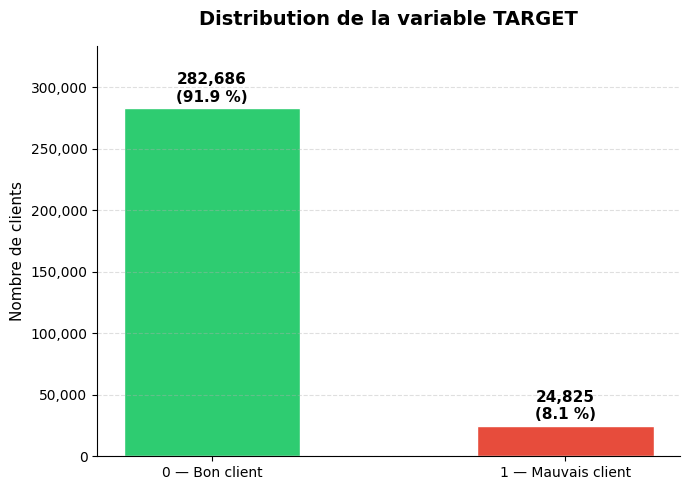

In [22]:
import matplotlib.pyplot as plt
import os

fig, ax = plt.subplots(figsize=(7, 5))

labels = ['0 — Bon client', '1 — Mauvais client']
colors = ['#2ecc71', '#e74c3c']  # vert, rouge

bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)

# Valeur exacte + pourcentage au-dessus de chaque barre
for bar, count, pct in zip(bars, counts.values, pcts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3000,
        f"{count:,}\n({pct:.1f} %)",
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title("Distribution de la variable TARGET", fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Nombre de clients", fontsize=11)
ax.set_ylim(0, counts.max() * 1.18)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

# Sauvegarde dans graphiques/
GRAPH_PATH = os.path.join(os.path.dirname('/home/bdb/Bureau/P6/Initiez-vous-au-MLOps/notebook.ipynb'), 'graphiques')
plt.savefig(os.path.join(GRAPH_PATH, 'target_distribution.png'), dpi=150, bbox_inches='tight')
print(f"Graphique sauvegardé : graphiques/target_distribution.png")

plt.show()

---

## Résumé — 1.3 La variable cible (TARGET)

| Classe | Signification | Effectif | Proportion |
|---|---|---|---|
| **0** | Bon client (remboursement OK) | 282 686 | 91,9 % |
| **1** | Mauvais client (difficultés de paiement) | 24 825 | 8,1 % |

**Ratio de déséquilibre :** environ 1 mauvais client pour 11 bons clients.

**Implication pour la modélisation :** ce fort déséquilibre (8 % vs 92 %) signifie qu'un modèle naïf qui prédit toujours 0 aurait déjà 91,9 % de précision — il faudra utiliser des techniques comme le rééchantillonnage (SMOTE, under-sampling) ou ajuster les poids des classes pour que le modèle apprenne réellement à détecter les mauvais payeurs.

---

## Phase 1 — 1.4 Valeurs manquantes

### Objectif
Identifier les colonnes incomplètes dans `application_train` et visualiser leur taux de remplissage — en filtrant sur les colonnes concernées pour que le graphique reste lisible.

### Étape 1 — Identifier les colonnes avec des valeurs manquantes

On filtre sur les colonnes qui ont au moins 1 NaN, puis on affiche combien sont concernées.

In [23]:
# Colonnes avec au moins 1 valeur manquante
mask_nan = application_train.isnull().sum() > 0
cols_manquantes = application_train.columns[mask_nan].tolist()

total_cols = application_train.shape[1]
print("=" * 50)
print("VALEURS MANQUANTES — application_train")
print("=" * 50)
print(f"  Colonnes avec NaN : {len(cols_manquantes)} sur {total_cols}")
print(f"  Colonnes complètes: {total_cols - len(cols_manquantes)} sur {total_cols}")
print("=" * 50)

VALEURS MANQUANTES — application_train
  Colonnes avec NaN : 67 sur 122
  Colonnes complètes: 55 sur 122


### Étape 2 — Tableau des taux de valeurs manquantes

Classement du plus incomplet au plus complet, avec le nombre brut et le pourcentage.

In [24]:
# Tableau classé par taux de NaN décroissant
n_rows = application_train.shape[0]
nan_counts = application_train[cols_manquantes].isnull().sum()

tableau_nan = pd.DataFrame({
    'nb_manquants': nan_counts,
    'pct_manquants': (nan_counts / n_rows * 100).round(1)
}).sort_values('pct_manquants', ascending=False)

print(f"{'Colonne':<45} {'NaN':>7} {'%':>7}")
print("-" * 62)
for col, row in tableau_nan.iterrows():
    print(f"{col:<45} {int(row['nb_manquants']):>7,} {row['pct_manquants']:>6.1f}%")

Colonne                                           NaN       %
--------------------------------------------------------------
COMMONAREA_MEDI                               214,865   69.9%
COMMONAREA_AVG                                214,865   69.9%
COMMONAREA_MODE                               214,865   69.9%
NONLIVINGAPARTMENTS_MEDI                      213,514   69.4%
NONLIVINGAPARTMENTS_MODE                      213,514   69.4%
NONLIVINGAPARTMENTS_AVG                       213,514   69.4%
LIVINGAPARTMENTS_MODE                         210,199   68.4%
LIVINGAPARTMENTS_MEDI                         210,199   68.4%
LIVINGAPARTMENTS_AVG                          210,199   68.4%
FONDKAPREMONT_MODE                            210,295   68.4%
FLOORSMIN_MODE                                208,642   67.8%
FLOORSMIN_MEDI                                208,642   67.8%
FLOORSMIN_AVG                                 208,642   67.8%
YEARS_BUILD_MODE                              204,488   66.5%
YEARS_B

### Étape 3 — Patterns de valeurs manquantes (colonnes > 40 % de NaN)

On filtre les colonnes avec plus de 40 % de NaN et on trace `msno.matrix` pour visualiser les **patterns** de valeurs manquantes.

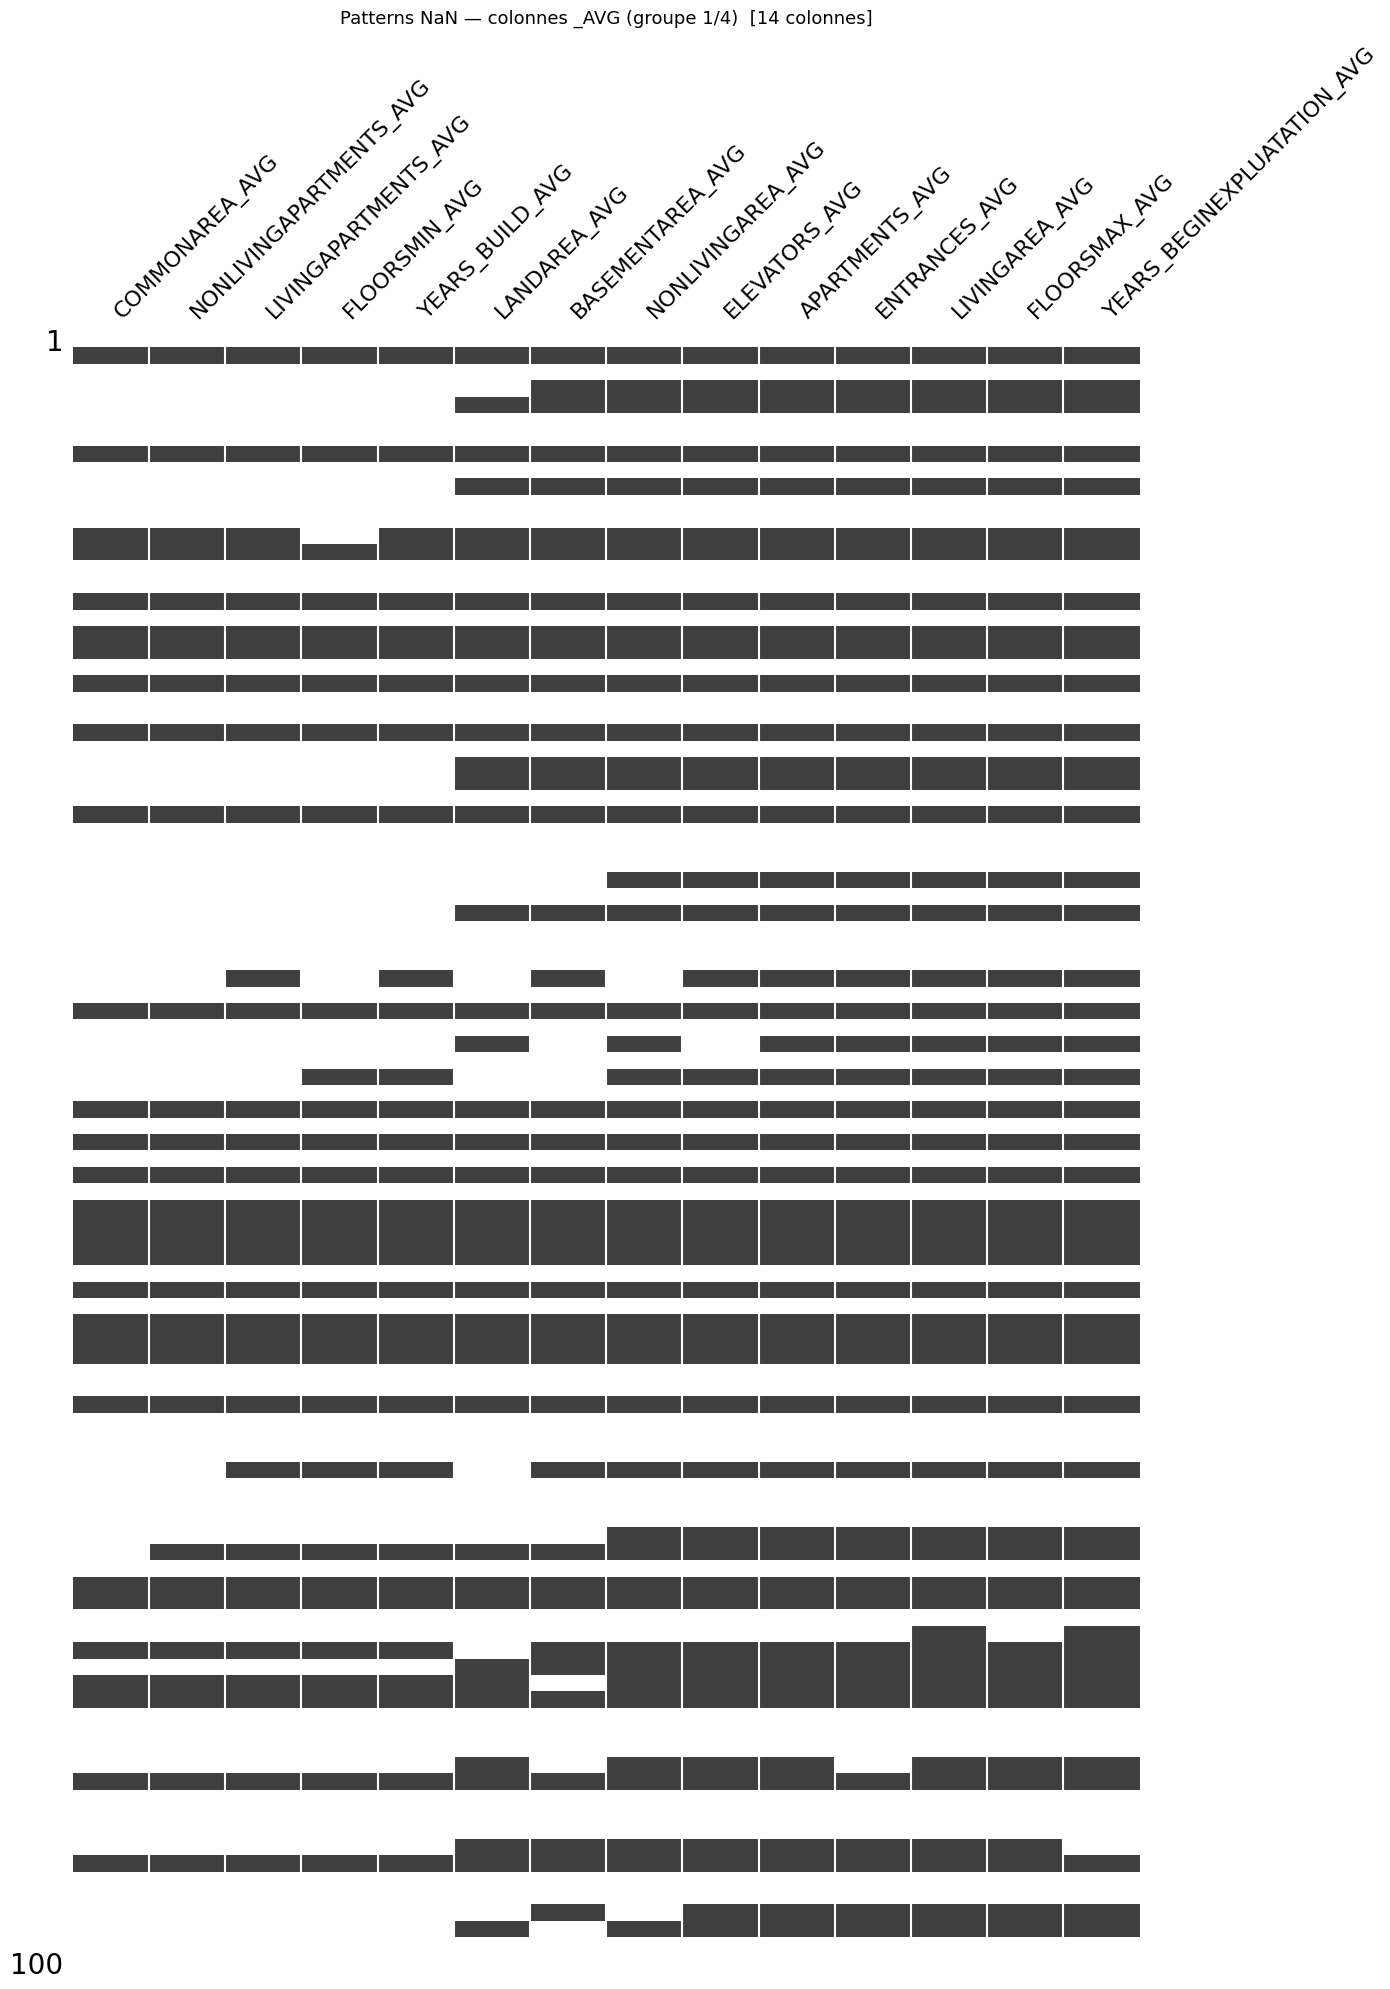

Graphique sauvegardé : graphiques/missingno_avg.png  (14 colonnes)


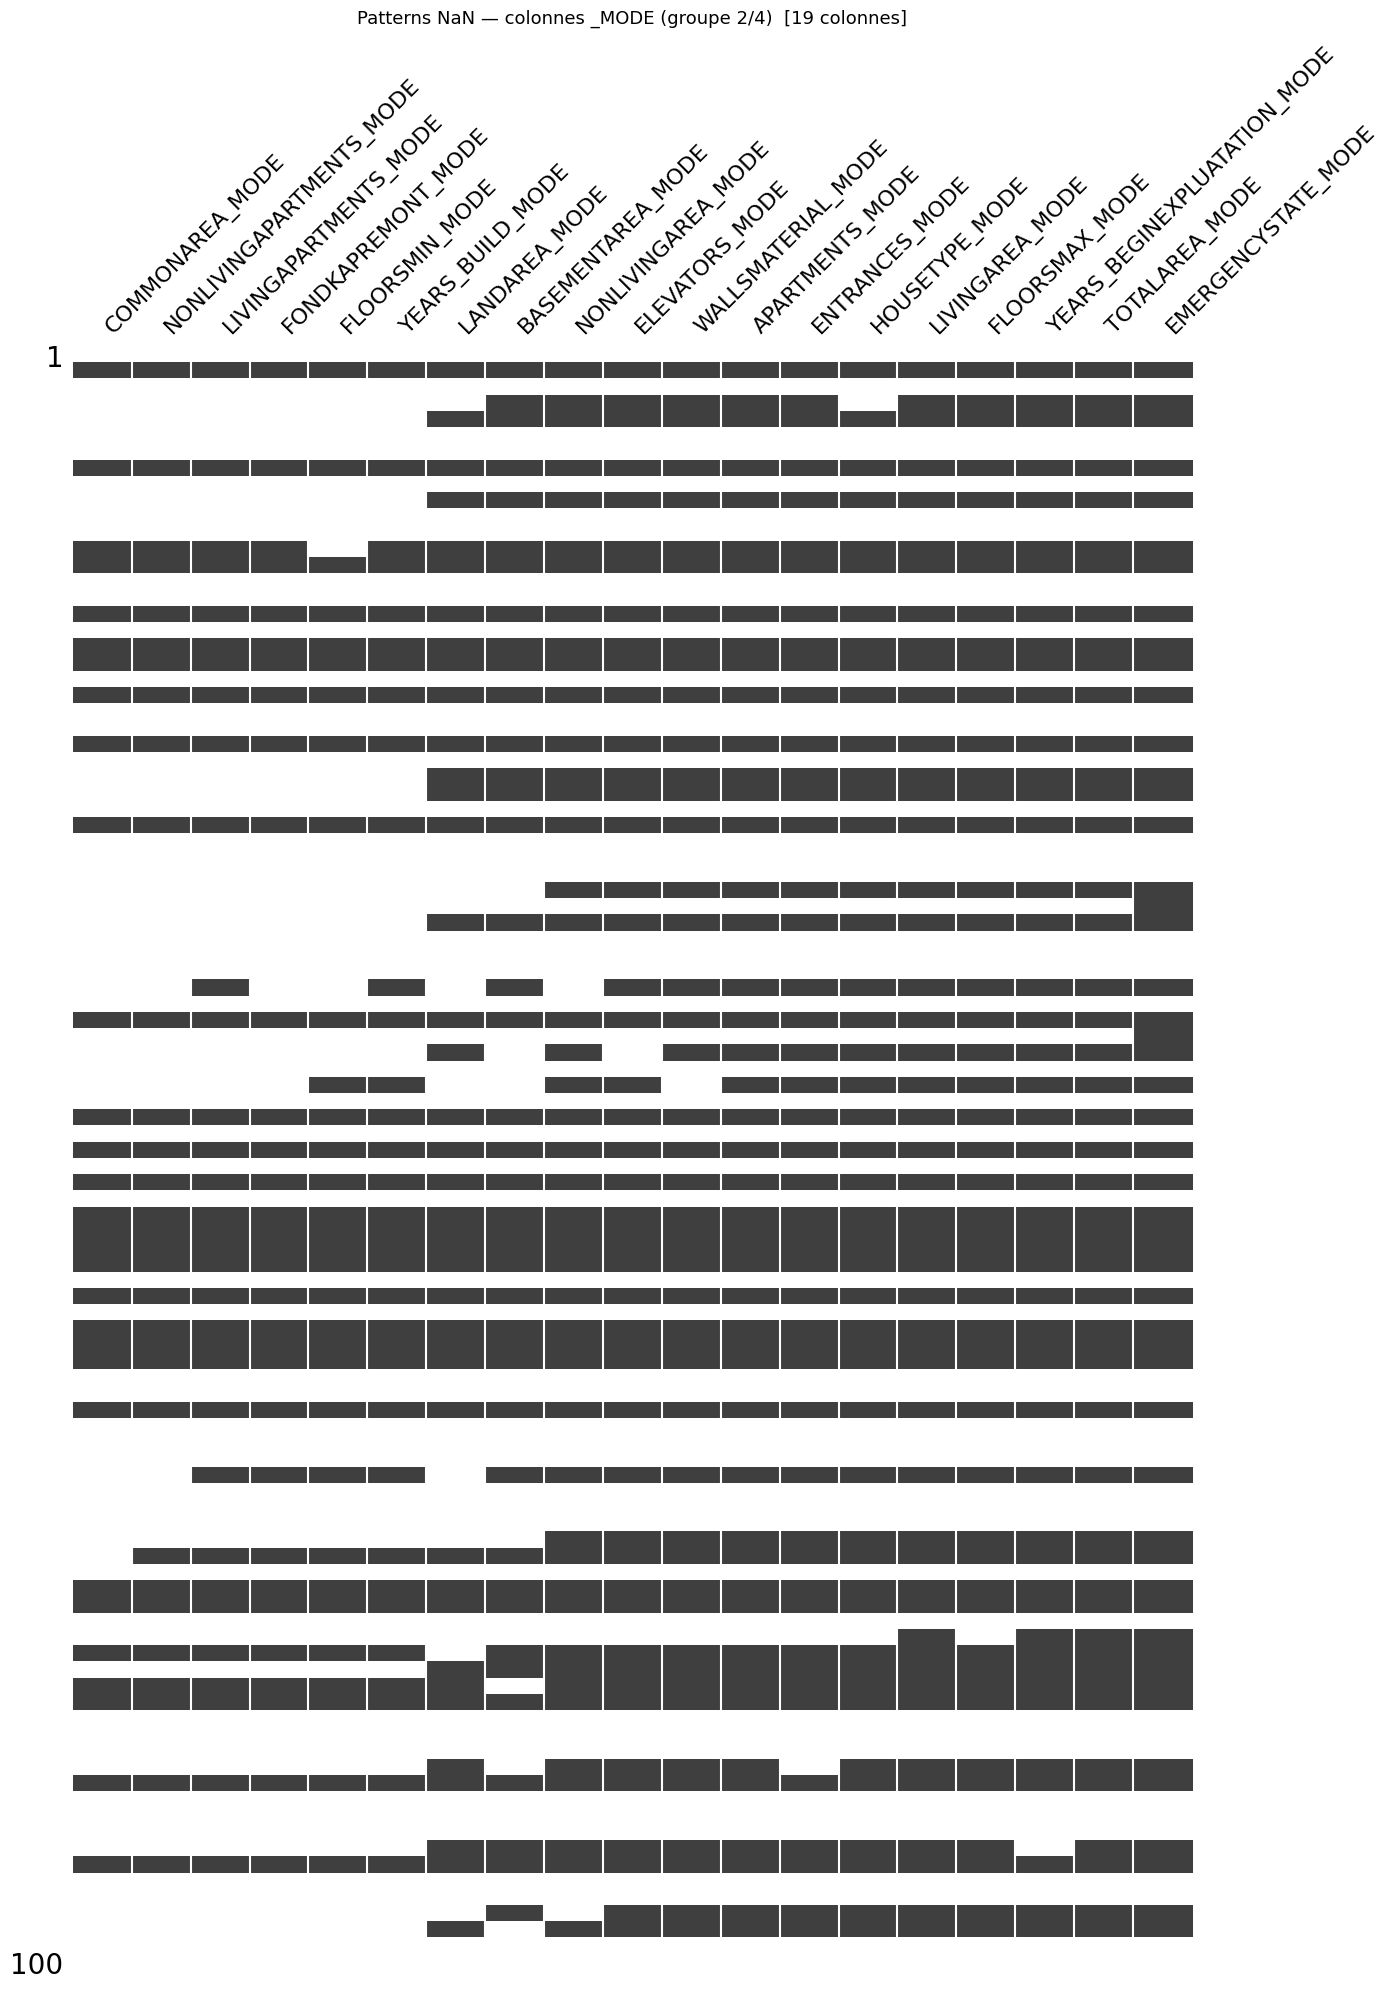

Graphique sauvegardé : graphiques/missingno_mode.png  (19 colonnes)


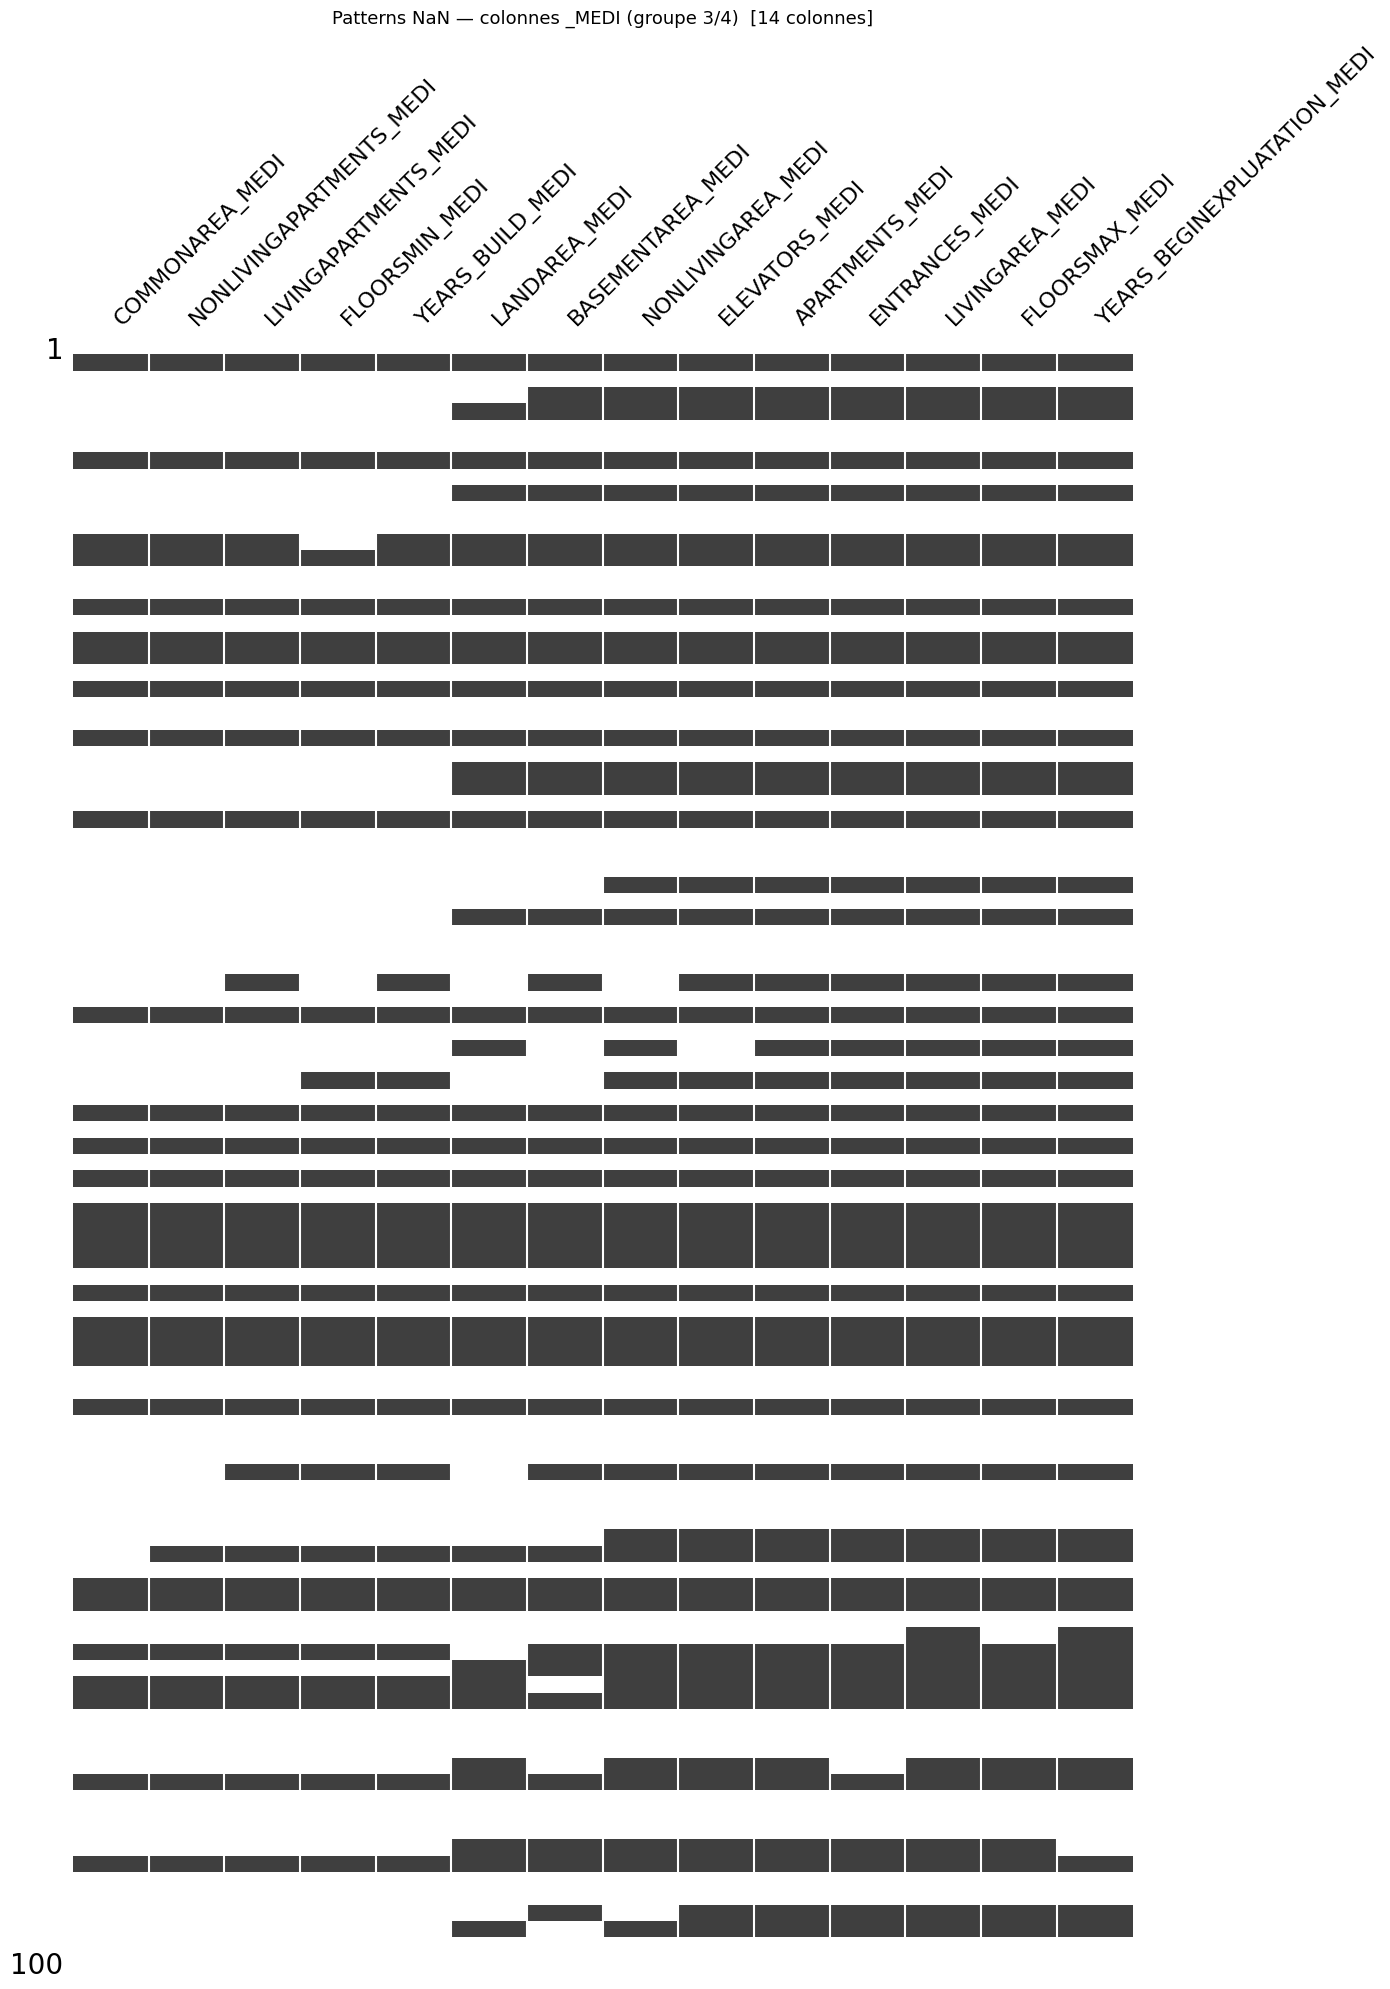

Graphique sauvegardé : graphiques/missingno_medi.png  (14 colonnes)


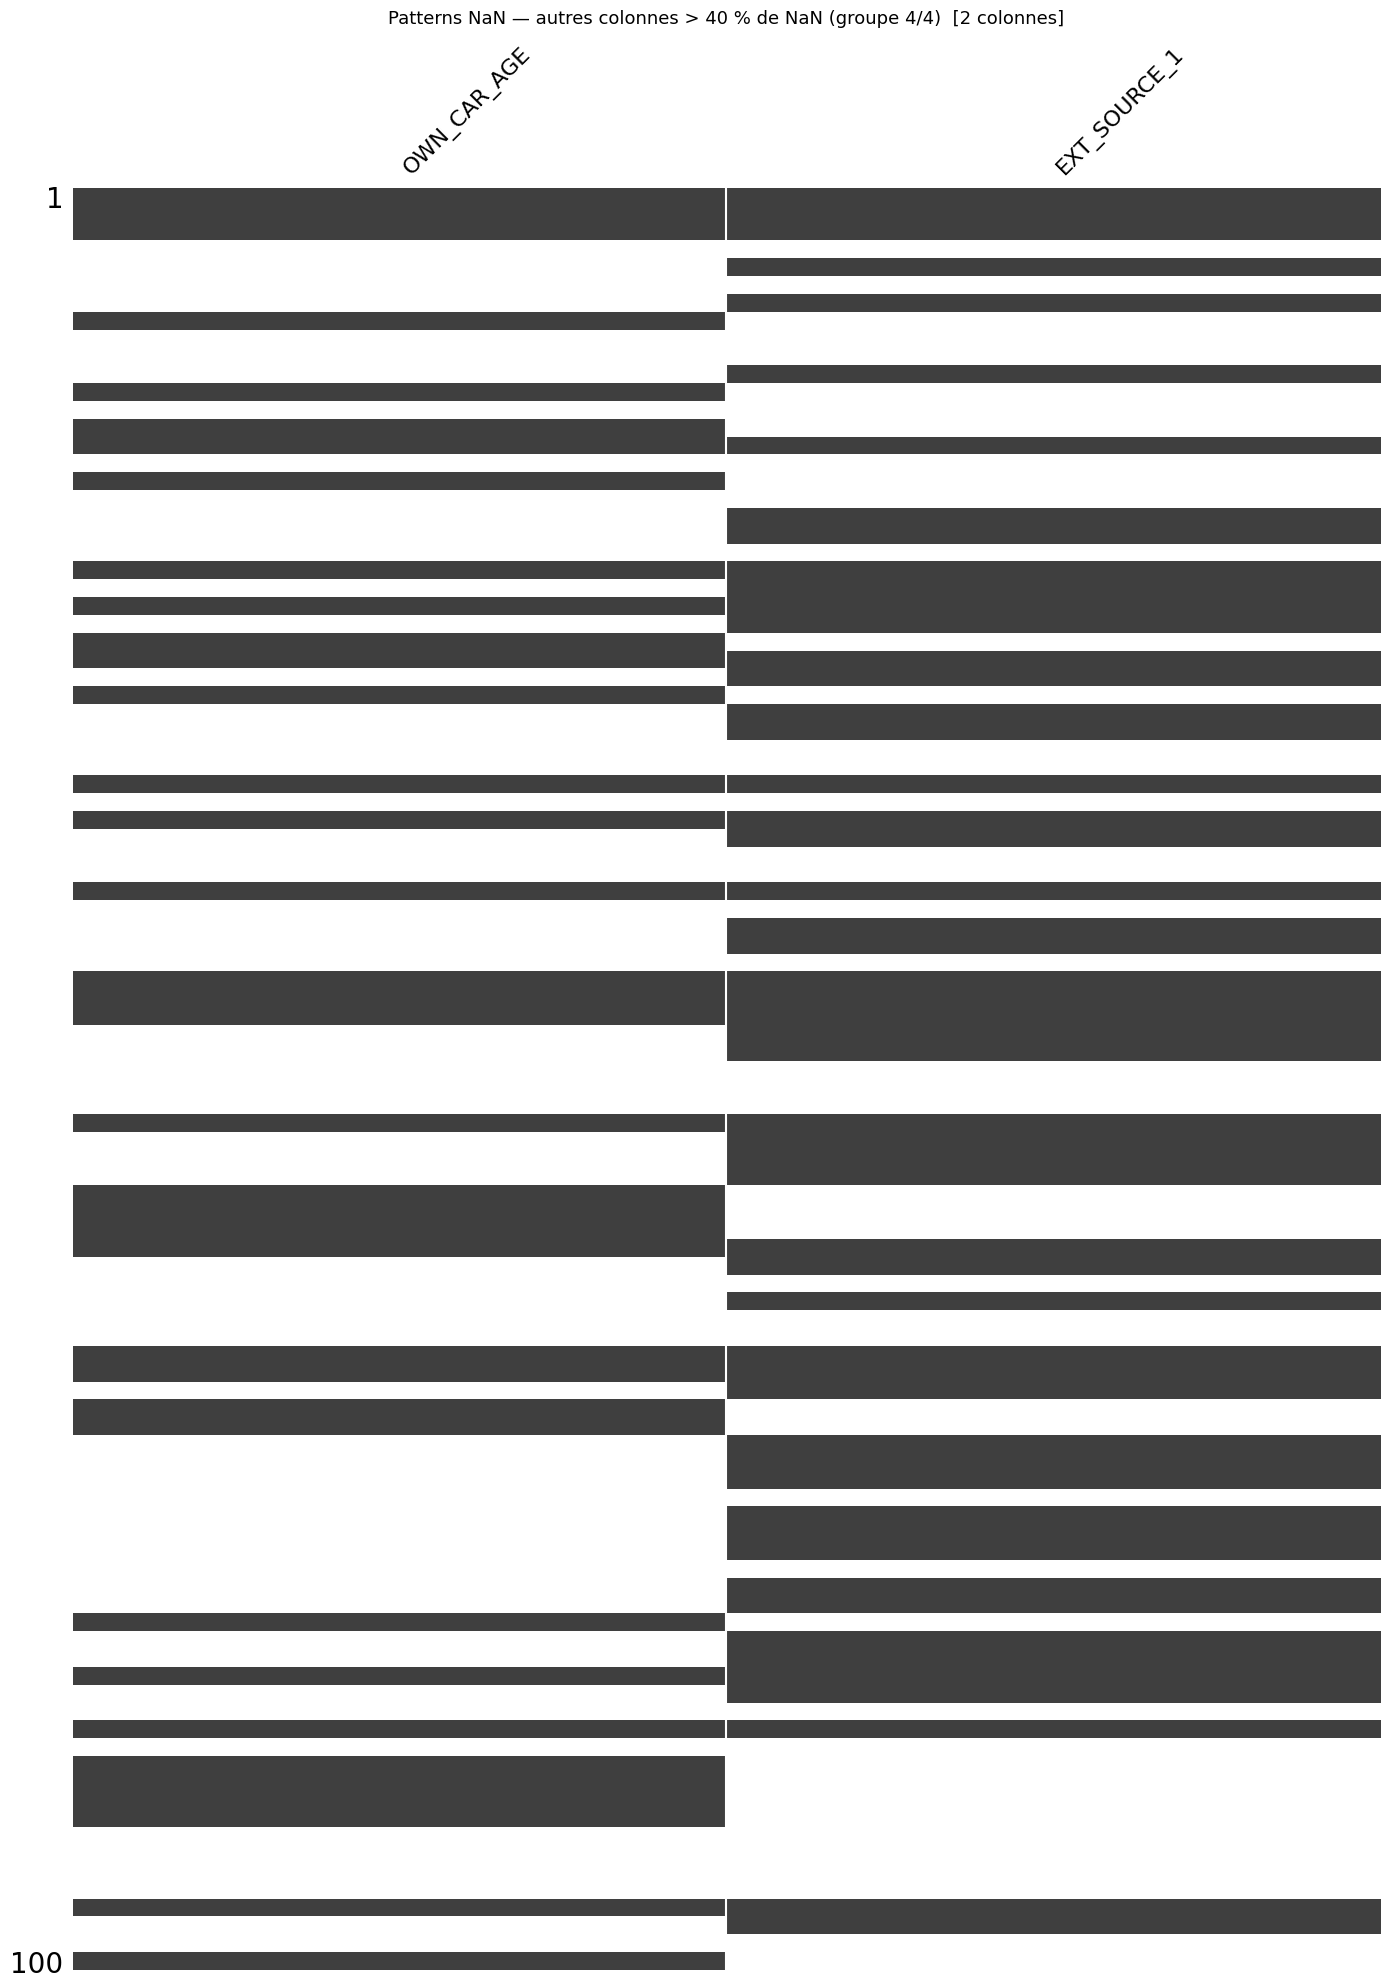

Graphique sauvegardé : graphiques/missingno_reste.png  (2 colonnes)


In [25]:
import missingno as msno
import matplotlib.pyplot as plt
import os

# Colonnes avec plus de 40 % de NaN
cols_sup40 = tableau_nan[tableau_nan['pct_manquants'] > 40].index.tolist()

# Colonnes ne finissant ni par _AVG, ni _MODE, ni _MEDI (ex : OWN_CAR_AGE, EXT_SOURCE_1, ...)
cols_reste = [
    c for c in cols_sup40
    if not c.endswith('_AVG') and not c.endswith('_MODE') and not c.endswith('_MEDI')
]

os.makedirs('graphiques', exist_ok=True)

groupes = [
    ('_AVG',  'missingno_avg.png',    '1/4', cols_sup40),
    ('_MODE', 'missingno_mode.png',   '2/4', cols_sup40),
    ('_MEDI', 'missingno_medi.png',   '3/4', cols_sup40),
    ('',      'missingno_reste.png',  '4/4', cols_reste),
]

for suffixe, fichier, numero, source in groupes:
    cols_groupe = [c for c in source if c.endswith(suffixe)] if suffixe else source

    if not cols_groupe:
        print(f"Groupe {suffixe or 'reste'} : aucune colonne trouvée — graphique ignoré.")
        continue

    df_sample = application_train[cols_groupe].sample(
        n=min(100, len(application_train)), random_state=42
    )

    fig, ax = plt.subplots(figsize=(14, 20))
    msno.matrix(df_sample, ax=ax, sparkline=False)
    label = f"colonnes {suffixe}" if suffixe else "autres colonnes > 40 % de NaN"
    ax.set_title(
        f"Patterns NaN — {label} (groupe {numero})  [{len(cols_groupe)} colonnes]",
        fontsize=13, pad=14
    )
    plt.tight_layout()
    plt.savefig(f'graphiques/{fichier}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Graphique sauvegardé : graphiques/{fichier}  ({len(cols_groupe)} colonnes)")

In [26]:
# Répartition par seuil de NaN
sup_40   = (tableau_nan['pct_manquants'] > 40).sum()
entre    = ((tableau_nan['pct_manquants'] >= 10) & (tableau_nan['pct_manquants'] <= 40)).sum()
inf_10   = (tableau_nan['pct_manquants'] < 10).sum()

print("=" * 50)
print("RÉPARTITION PAR SEUIL DE NaN")
print("=" * 50)
print(f"  > 40 % de NaN  : {sup_40:>3} colonnes  → candidats à la suppression")
print(f"  10 % à 40 %    : {entre:>3} colonnes  → imputation à envisager")
print(f"  < 10 % de NaN  : {inf_10:>3} colonnes  → imputation simple")
print("=" * 50)

RÉPARTITION PAR SEUIL DE NaN
  > 40 % de NaN  :  49 colonnes  → candidats à la suppression
  10 % à 40 %    :   8 colonnes  → imputation à envisager
  < 10 % de NaN  :  10 colonnes  → imputation simple


---

## Résumé — 1.4 Valeurs manquantes

**67 colonnes sur 122** ont au moins une valeur manquante.

**Répartition par seuil :**

| Seuil | Nb colonnes | Stratégie Phase 2 |
|---|---|---|
| **> 40 % de NaN** | 49 | Suppression — trop peu de données pour imputer |
| **10 % à 40 %** | 8 | Imputation (médiane pour numériques, mode pour catégorielles) |
| **< 10 % de NaN** | 10 | Imputation simple — impact faible |

> Les colonnes à fort taux de NaN appartiennent principalement au groupe des caractéristiques **logement** (`COMMONAREA_*`, `NONLIVINGAPARTMENTS_*`, etc.) — l'information était probablement non collectée pour une grande partie des clients.

---

## Phase 1 — 1.5 Distributions des variables principales

### Objectif
Visualiser la forme des variables clés avant tout nettoyage : détecter les asymétries, valeurs aberrantes et déséquilibres qui guideront les choix de la Phase 2.

### Étape 1 — Variables numériques (grille 2×2)

On affiche les histogrammes de 4 variables numériques clés.
> **Note sur `DAYS_EMPLOYED`** : certaines valeurs valent 365 243 — c'est une valeur sentinelle du dataset Home Credit pour coder "sans emploi". On les filtre avant de tracer.

Sauvegardé : graphiques/distributions_numeriques.png


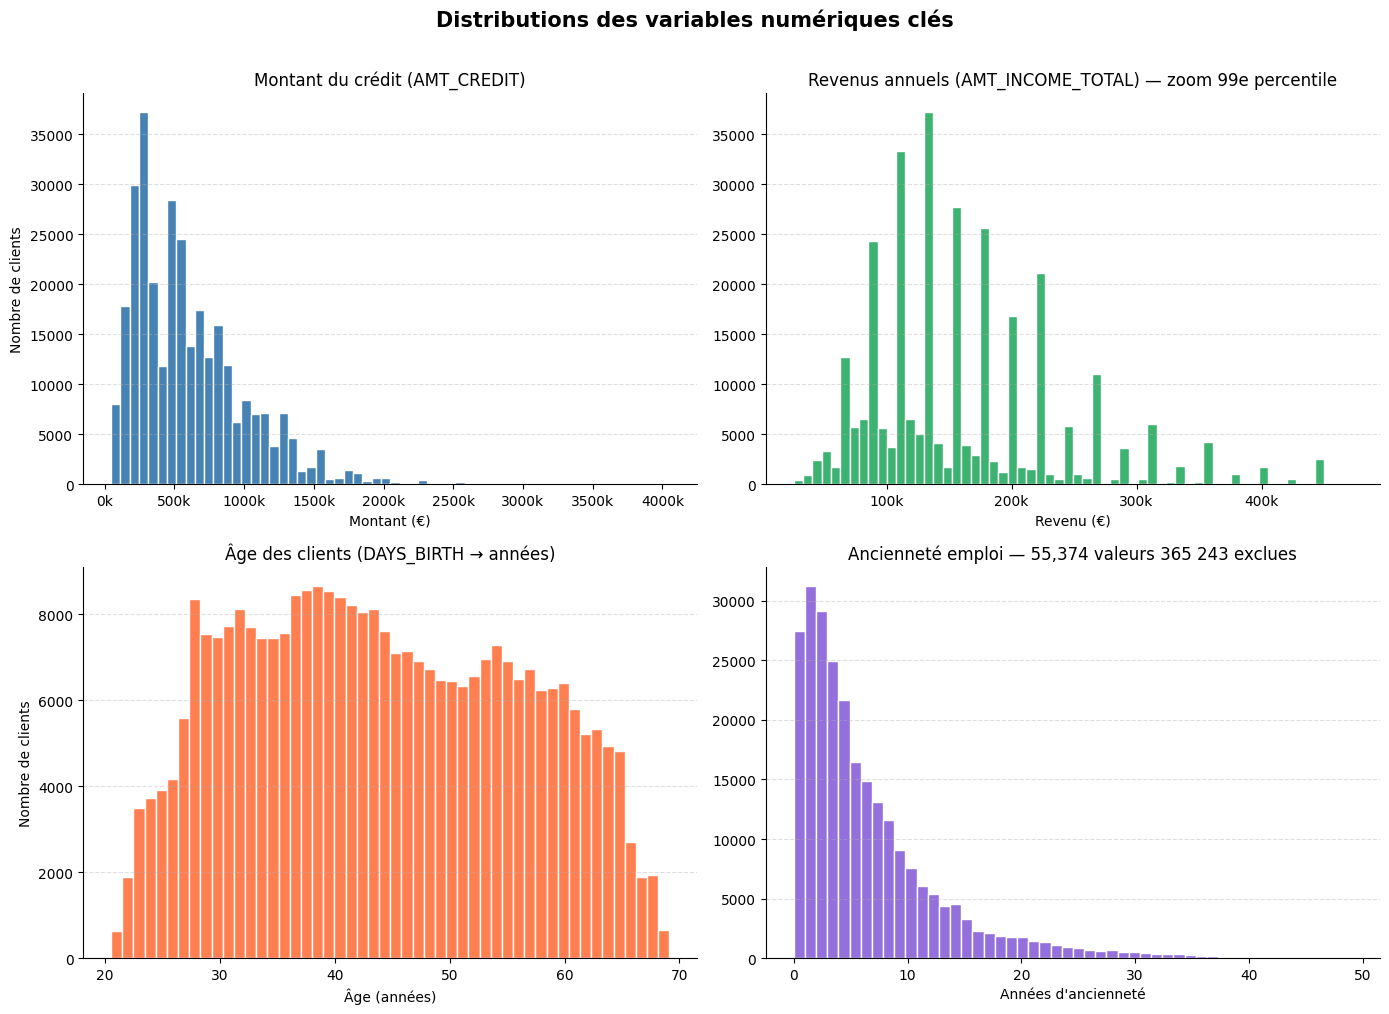

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Préparation des séries (conversions + filtre aberrant)
age_ans          = application_train['DAYS_BIRTH'].abs() / 365
anciennete_ans   = application_train.loc[
    application_train['DAYS_EMPLOYED'] != 365243, 'DAYS_EMPLOYED'
].abs() / 365
n_aberrants      = (application_train['DAYS_EMPLOYED'] == 365243).sum()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distributions des variables numériques clés", fontsize=15, fontweight='bold', y=1.01)

# — AMT_CREDIT
axes[0, 0].hist(application_train['AMT_CREDIT'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0, 0].set_title("Montant du crédit (AMT_CREDIT)")
axes[0, 0].set_xlabel("Montant (€)")
axes[0, 0].set_ylabel("Nombre de clients")
axes[0, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

# — AMT_INCOME_TOTAL (zoom : on écarte le top 1% pour ne pas écraser le graphique)
revenu_p99 = application_train['AMT_INCOME_TOTAL'].quantile(0.99)
axes[0, 1].hist(application_train.loc[application_train['AMT_INCOME_TOTAL'] <= revenu_p99, 'AMT_INCOME_TOTAL'],
                bins=60, color='mediumseagreen', edgecolor='white')
axes[0, 1].set_title("Revenus annuels (AMT_INCOME_TOTAL) — zoom 99e percentile")
axes[0, 1].set_xlabel("Revenu (€)")
axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

# — ÂGE
axes[1, 0].hist(age_ans, bins=50, color='coral', edgecolor='white')
axes[1, 0].set_title("Âge des clients (DAYS_BIRTH → années)")
axes[1, 0].set_xlabel("Âge (années)")
axes[1, 0].set_ylabel("Nombre de clients")

# — ANCIENNETÉ EMPLOI
axes[1, 1].hist(anciennete_ans, bins=50, color='mediumpurple', edgecolor='white')
axes[1, 1].set_title(f"Ancienneté emploi — {n_aberrants:,} valeurs 365 243 exclues")
axes[1, 1].set_xlabel("Années d'ancienneté")

for ax in axes.flat:
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('graphiques/distributions_numeriques.png', dpi=150, bbox_inches='tight')
print("Sauvegardé : graphiques/distributions_numeriques.png")
plt.show()

### Étape 2 — Variables catégorielles (grille 2×2)

On visualise 4 variables qualitatives avec leur décompte de modalités.
La 4e variable choisie est `NAME_FAMILY_STATUS` (situation familiale), très liée au profil de risque.

Sauvegardé : graphiques/distributions_categorielles.png


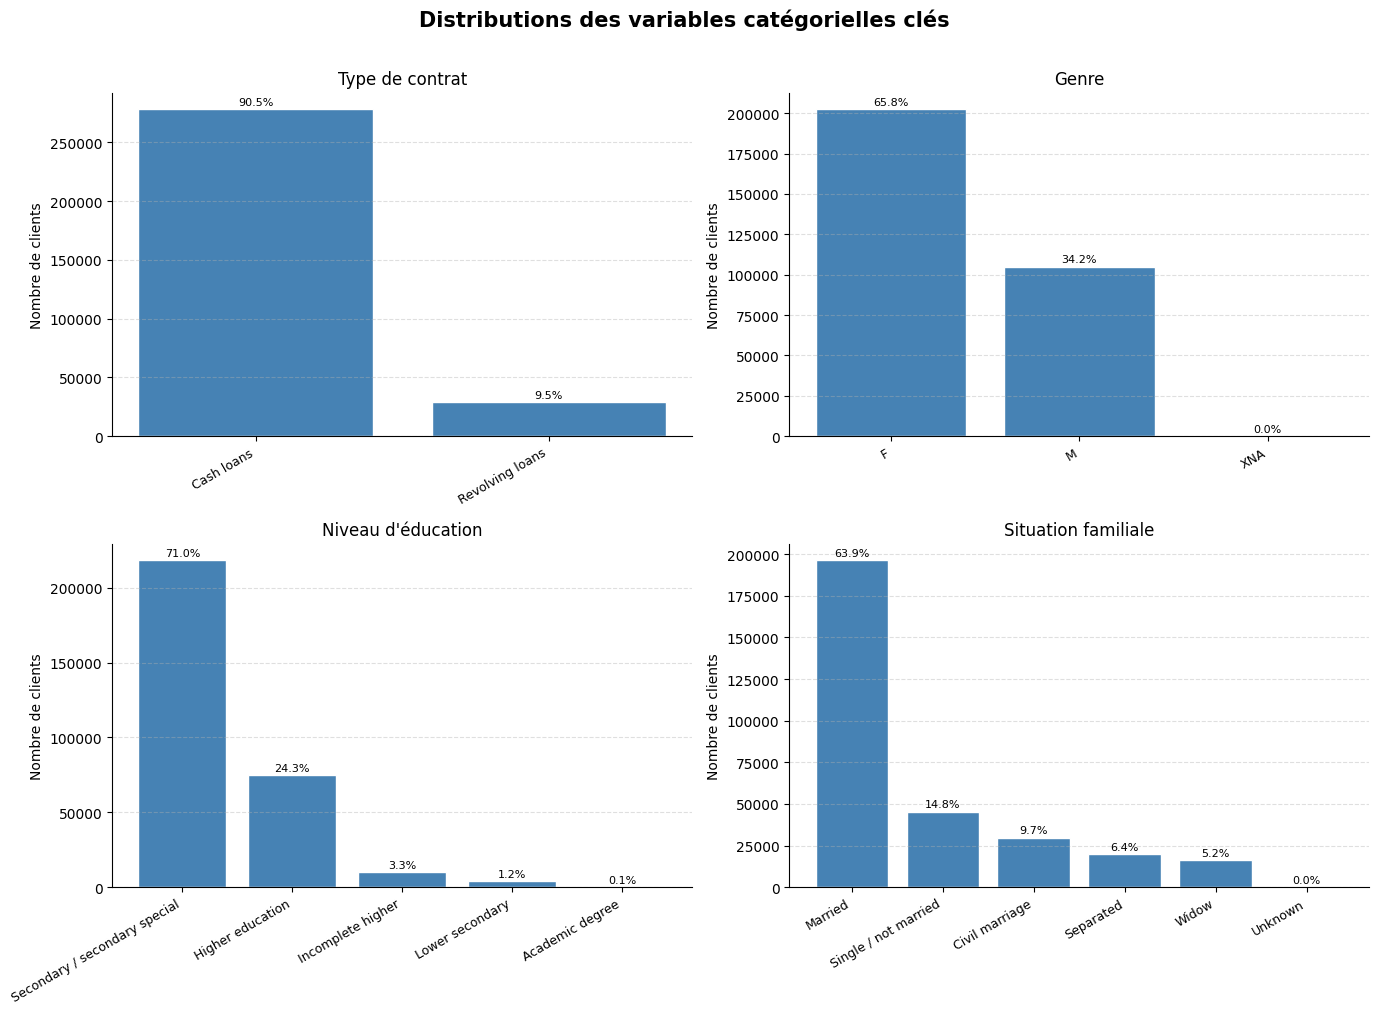

In [28]:
vars_cat = {
    'NAME_CONTRACT_TYPE' : "Type de contrat",
    'CODE_GENDER'        : "Genre",
    'NAME_EDUCATION_TYPE': "Niveau d'éducation",
    'NAME_FAMILY_STATUS' : "Situation familiale",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distributions des variables catégorielles clés", fontsize=15, fontweight='bold', y=1.01)

for ax, (col, titre) in zip(axes.flat, vars_cat.items()):
    counts = application_train[col].value_counts()
    bars = ax.bar(range(len(counts)), counts.values, color='steelblue', edgecolor='white')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(titre)
    ax.set_ylabel("Nombre de clients")
    # Pourcentage au-dessus de chaque barre
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.005,
                f"{val/total:.1%}", ha='center', va='bottom', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('graphiques/distributions_categorielles.png', dpi=150, bbox_inches='tight')
print("Sauvegardé : graphiques/distributions_categorielles.png")
plt.show()

---

## Résumé — 1.5 Distributions des variables principales

### Variables numériques

| Variable | Observation clé | Anomalie repérée |
|---|---|---|
| **AMT_CREDIT** | Distribution asymétrique à droite — la majorité des crédits sont petits, quelques très grands crédits tirent la queue vers la droite | Pas de valeur aberrante technique, mais des outliers extrêmes à surveiller |
| **AMT_INCOME_TOTAL** | Forte asymétrie droite — quelques revenus très élevés (top 1 % filtré pour le graphique) écrasent la majorité | Outliers à plusieurs millions → à plafonner ou logger en Phase 2 |
| **DAYS_BIRTH (âge)** | Distribution relativement uniforme entre 20 et 70 ans, légère sur-représentation des 30–50 ans | Aucune valeur aberrante |
| **DAYS_EMPLOYED (ancienneté)** | Concentrée sur 0–15 ans, queue droite modérée | **365 243** présent pour ~55 000 clients — valeur sentinelle "sans emploi" à remplacer par NaN en Phase 2 |

### Variables catégorielles

| Variable | Observation clé |
|---|---|
| **NAME_CONTRACT_TYPE** | Très déséquilibré : les crédits Cash dominent largement face aux Revolving |
| **CODE_GENDER** | Majorité de femmes (~65 %) — la variable XNA (indéfini) devra être traitée |
| **NAME_EDUCATION_TYPE** | Le niveau "Secondary / secondary special" est de loin le plus représenté |
| **NAME_FAMILY_STATUS** | "Married" domine, suivi de "Single/not married" — information utile pour le scoring |

#### Vérification — Identification des clients avec DAYS_EMPLOYED = 365 243

Avant de passer en Phase 2, on confirme l'origine de la valeur sentinelle et on crée le flag d'anomalie qui sera conservé comme feature.

In [29]:
# Qui sont les clients avec DAYS_EMPLOYED = 365243 ?
mask = application_train['DAYS_EMPLOYED'] == 365243

print(application_train[mask]['NAME_INCOME_TYPE'].value_counts())

NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64


In [30]:
# Étape 1 : créer le flag AVANT de remplacer
application_train['FLAG_EMPLOYED_ANOMALY'] = (
    application_train['DAYS_EMPLOYED'] == 365243
).astype(int)

# Étape 2 : remplacer par NaN
application_train['DAYS_EMPLOYED'] = application_train['DAYS_EMPLOYED'].replace(
    365243, np.nan
)

---

## Phase 1 — 1.6 Analyse bivariée TARGET

### Objectif
Étudier la relation entre TARGET et les variables clés : comparer la distribution des bons clients (TARGET=0) vs mauvais clients (TARGET=1) pour les variables numériques, et calculer le taux de défaut par modalité pour les variables catégorielles.

### Étape 1 — Boxplots : variables numériques vs TARGET

Pour chaque variable, on sépare les clients `TARGET=0` (bon payeur) de `TARGET=1` (défaut) et on compare leurs distributions via un boxplot côte à côte.

> **Note :** `DAYS_BIRTH` est négatif dans le dataset (compté à rebours depuis la naissance). On prend la valeur absolue et on divise par 365 pour obtenir un âge en années lisible. `EXT_SOURCE_2` a ~660 valeurs manquantes — on les exclut avec `.dropna()` avant le tracé.

Sauvegardé : graphiques/bivariate_numeric.png


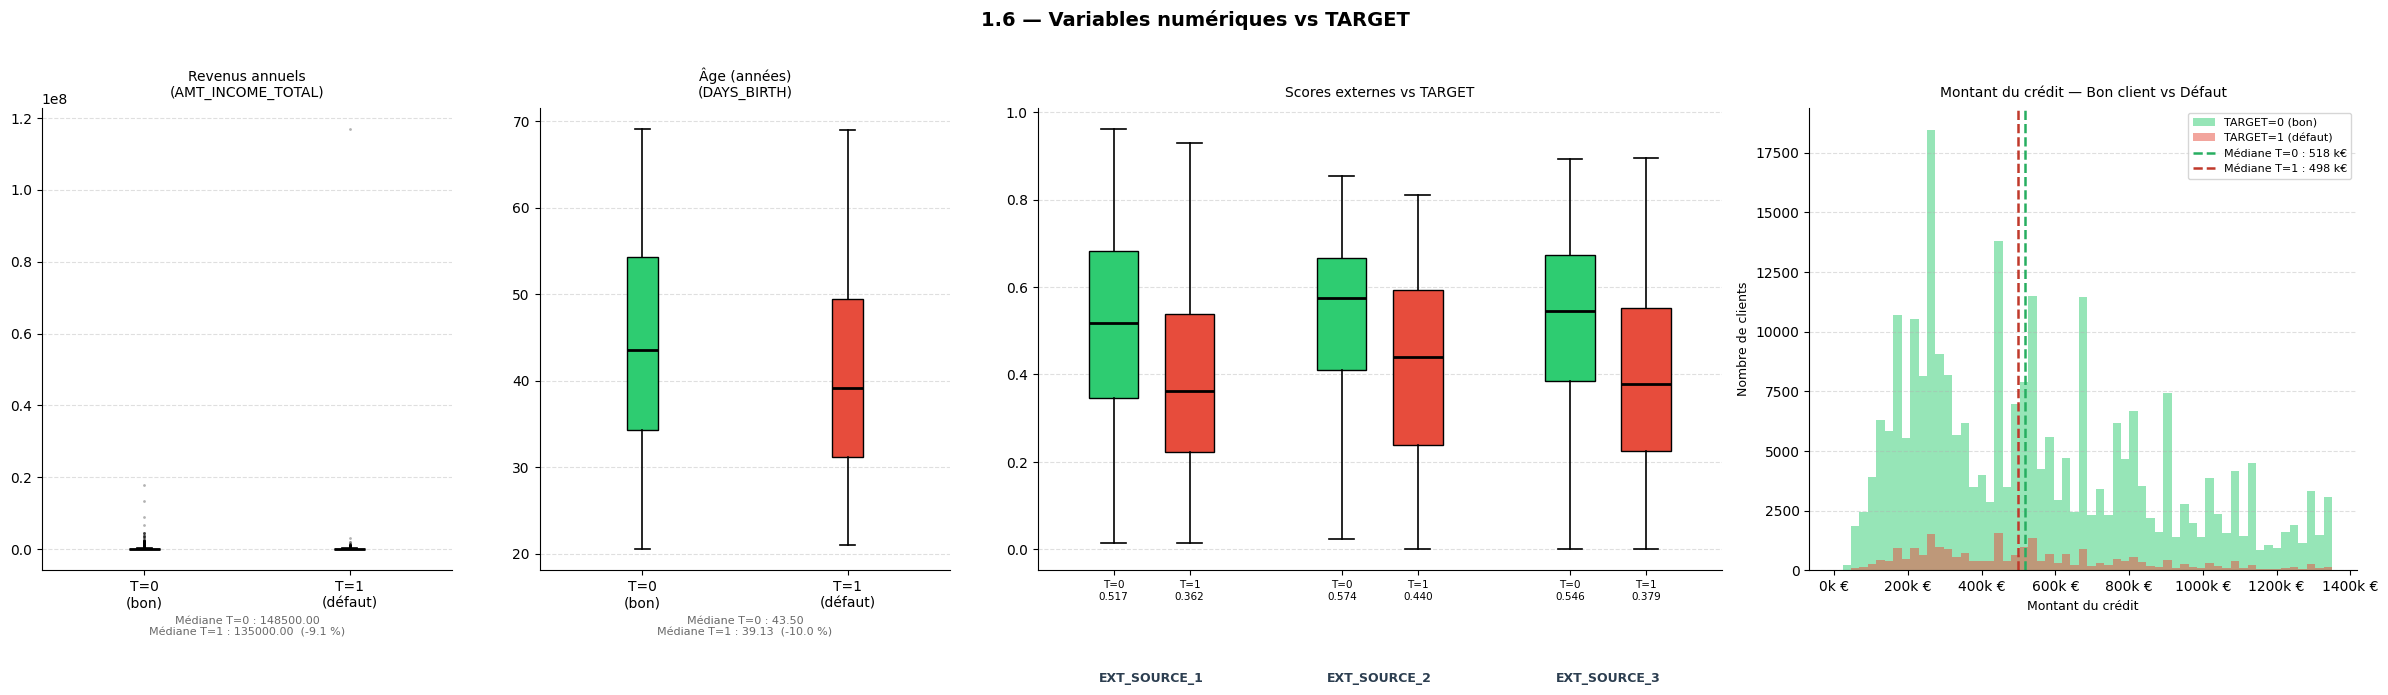

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.transforms import blended_transform_factory
import numpy as np
import os

# Conversion DAYS_BIRTH → âge positif en années
application_train['AGE_YEARS'] = application_train['DAYS_BIRTH'].abs() / 365

# ── 1. Boxplots pour 2 variables simples ──────────────────────────────────────
bp_vars   = ['AMT_INCOME_TOTAL', 'AGE_YEARS']
bp_labels = [
    'Revenus annuels\n(AMT_INCOME_TOTAL)',
    'Âge (années)\n(DAYS_BIRTH)',
]

fig, axes = plt.subplots(1, 4, figsize=(24, 7),
                         gridspec_kw={'width_ratios': [3, 3, 5, 4]})
fig.suptitle("1.6 — Variables numériques vs TARGET", fontsize=14, fontweight='bold', y=1.01)

for ax, var, label in zip(axes[:2], bp_vars, bp_labels):
    data_0 = application_train.loc[application_train['TARGET'] == 0, var].dropna()
    data_1 = application_train.loc[application_train['TARGET'] == 1, var].dropna()
    bp = ax.boxplot(
        [data_0, data_1],
        tick_labels=['T=0\n(bon)', 'T=1\n(défaut)'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='.', markersize=2, alpha=0.3),
    )
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    med_0 = data_0.median()
    med_1 = data_1.median()
    diff_pct = (med_1 - med_0) / med_0 * 100
    ax.set_title(label, fontsize=10, pad=8)
    ax.set_xlabel(
        f"Médiane T=0 : {med_0:.2f}\nMédiane T=1 : {med_1:.2f}  ({diff_pct:+.1f} %)",
        fontsize=8, color='dimgray'
    )
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

# ── 2. EXT_SOURCE_1 / 2 / 3 : 3 paires de boxplots côte à côte ───────────────
ax_ext = axes[2]
ext_vars  = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
positions = [1, 2, 4, 5, 7, 8]   # gap de 1 entre chaque paire pour visuellement grouper

data_ext = []
for var in ext_vars:
    data_ext.append(application_train.loc[application_train['TARGET'] == 0, var].dropna())
    data_ext.append(application_train.loc[application_train['TARGET'] == 1, var].dropna())

bp_ext = ax_ext.boxplot(
    data_ext,
    positions=positions,
    widths=0.65,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    showfliers=False,
)
for i, box in enumerate(bp_ext['boxes']):
    box.set_facecolor('#2ecc71' if i % 2 == 0 else '#e74c3c')

# Tick labels : "T=0\n0.xxx" et "T=1\n0.xxx"
tick_labels = []
for i, series in enumerate(data_ext):
    prefix = 'T=0' if i % 2 == 0 else 'T=1'
    tick_labels.append(f"{prefix}\n{series.median():.3f}")
ax_ext.set_xticks(positions)
ax_ext.set_xticklabels(tick_labels, fontsize=7.5)

# Étiquettes de groupe (nom de variable) centrées sous chaque paire
trans = blended_transform_factory(ax_ext.transData, ax_ext.transAxes)
for center, var in zip([1.5, 4.5, 7.5], ext_vars):
    ax_ext.text(center, -0.22, var, transform=trans,
                ha='center', va='top', fontsize=9, fontweight='bold', color='#2c3e50')

ax_ext.set_title("Scores externes vs TARGET", fontsize=10, pad=8)
ax_ext.set_xlim(0, 9)
ax_ext.grid(axis='y', linestyle='--', alpha=0.4)
ax_ext.spines[['top', 'right']].set_visible(False)

# ── 3. Histogramme superposé AMT_CREDIT (4e panneau) ─────────────────────────
ax_hist = axes[3]

credit_0 = application_train.loc[application_train['TARGET'] == 0, 'AMT_CREDIT'].dropna()
credit_1 = application_train.loc[application_train['TARGET'] == 1, 'AMT_CREDIT'].dropna()

# Fenêtre au 95e percentile — exclut la queue droite sans modifier les données
cap  = np.percentile(application_train['AMT_CREDIT'].dropna(), 95)
bins = np.linspace(0, cap, 60)

ax_hist.hist(credit_0[credit_0 <= cap], bins=bins,
             color='#2ecc71', alpha=0.5, label='TARGET=0 (bon)')
ax_hist.hist(credit_1[credit_1 <= cap], bins=bins,
             color='#e74c3c', alpha=0.5, label='TARGET=1 (défaut)')

med_c0 = credit_0.median()
med_c1 = credit_1.median()
ax_hist.axvline(med_c0, color='#27ae60', linewidth=1.8, linestyle='--',
                label=f'Médiane T=0 : {med_c0/1000:.0f} k€')
ax_hist.axvline(med_c1, color='#c0392b', linewidth=1.8, linestyle='--',
                label=f'Médiane T=1 : {med_c1/1000:.0f} k€')

ax_hist.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k €')
)
ax_hist.set_title("Montant du crédit — Bon client vs Défaut", fontsize=10, pad=8)
ax_hist.set_xlabel("Montant du crédit", fontsize=9)
ax_hist.set_ylabel("Nombre de clients", fontsize=9)
ax_hist.legend(fontsize=8)
ax_hist.grid(axis='y', linestyle='--', alpha=0.4)
ax_hist.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
os.makedirs('graphiques', exist_ok=True)
plt.savefig('graphiques/bivariate_numeric.png', dpi=150, bbox_inches='tight')
print("Sauvegardé : graphiques/bivariate_numeric.png")
plt.show()

### Étape 2 — Taux de défaut par variable catégorielle

Pour chaque modalité, on calcule la **moyenne de TARGET** (= proportion de `TARGET=1`), puis on trie du plus risqué au moins risqué.  
La couleur varie du rouge (risque élevé) au vert (risque faible) via le colormap `RdYlGn_r`.

Sauvegardé : graphiques/bivariate_categorical.png


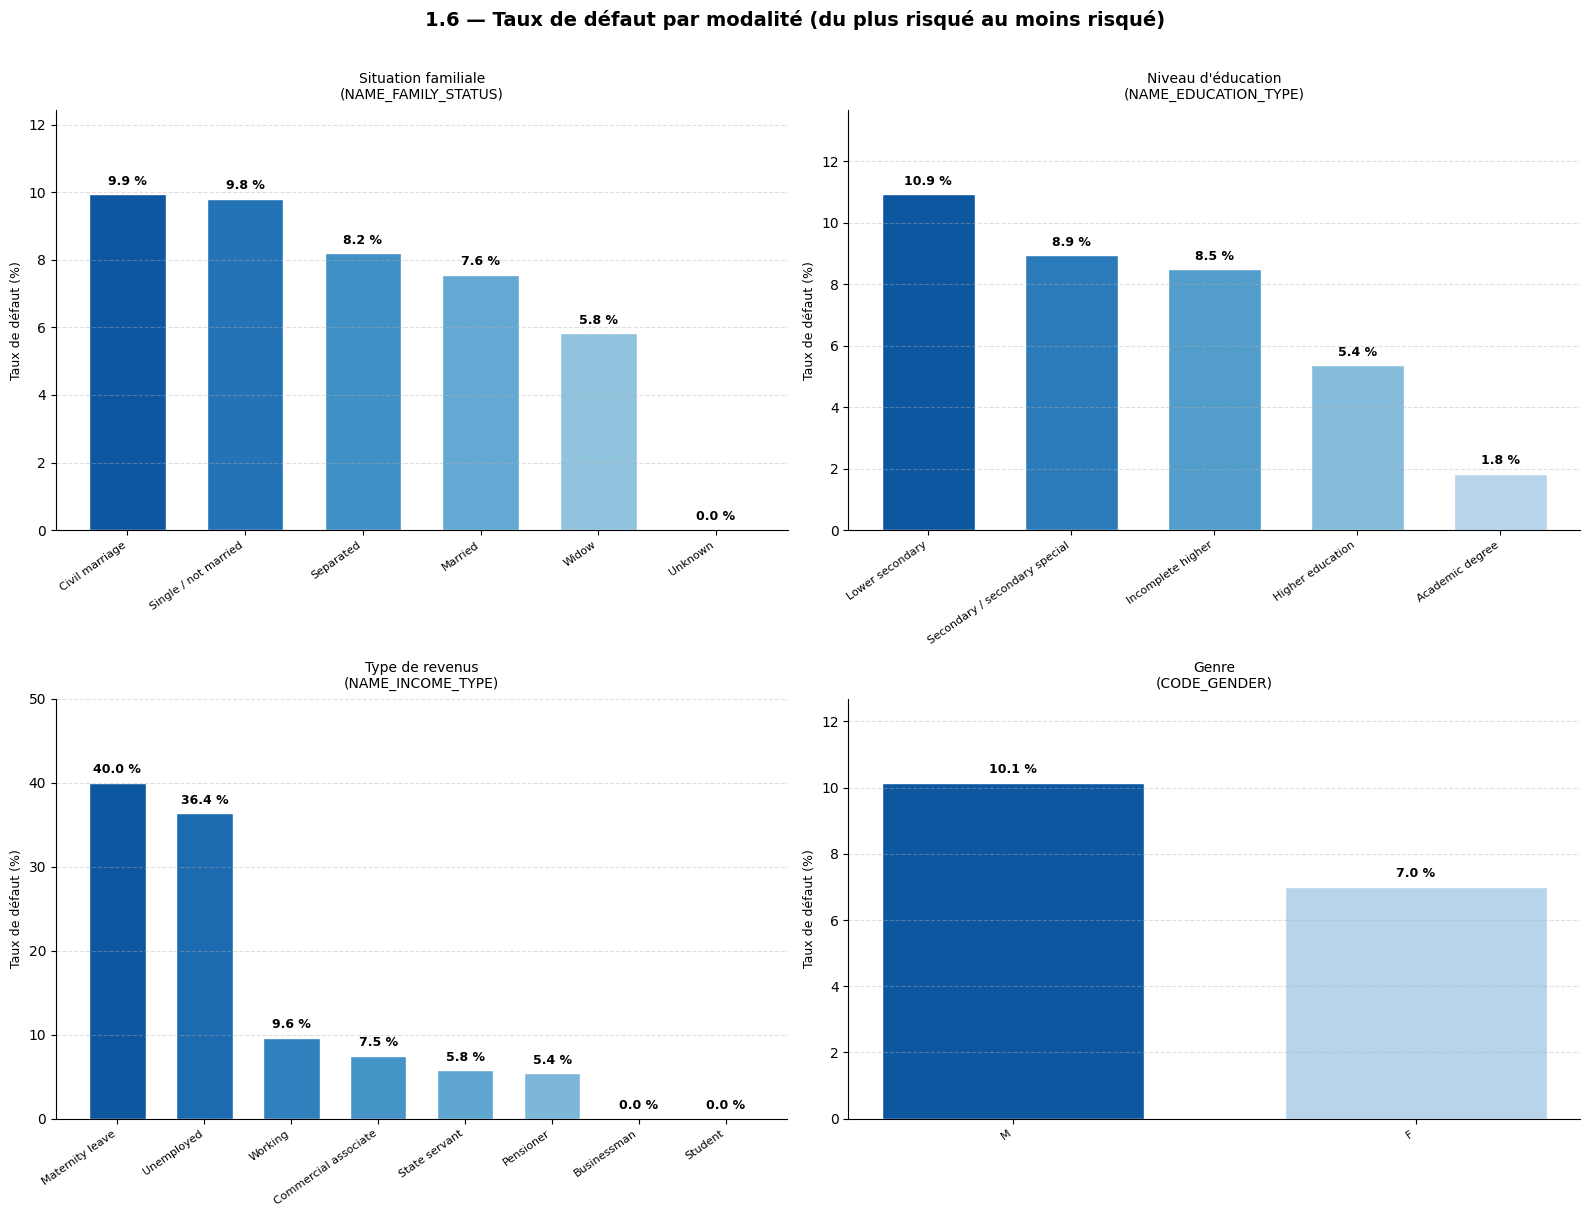

In [32]:
cat_vars = ['NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE', 'CODE_GENDER']
cat_labels = [
    'Situation familiale\n(NAME_FAMILY_STATUS)',
    "Niveau d'éducation\n(NAME_EDUCATION_TYPE)",
    'Type de revenus\n(NAME_INCOME_TYPE)',
    'Genre\n(CODE_GENDER)',
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "1.6 — Taux de défaut par modalité (du plus risqué au moins risqué)",
    fontsize=14, fontweight='bold', y=1.01
)

for ax, var, label in zip(axes.flat, cat_vars, cat_labels):
    # CODE_GENDER : XNA remplacé plus tard dans le pipeline — on l'exclut ici
    if var == 'CODE_GENDER':
        data = application_train[application_train['CODE_GENDER'] != 'XNA']
    else:
        data = application_train

    default_rate = (
        data.groupby(var)['TARGET']
        .mean()
        .sort_values(ascending=False)
    )
    n = len(default_rate)
    # Palette bleue : foncé = plus risqué, clair = moins risqué (distinct de rouge/vert TARGET)
    colors = [plt.cm.Blues(v) for v in np.linspace(0.85, 0.3, n)]
    bars = ax.bar(range(n), default_rate.values * 100, color=colors, edgecolor='white', width=0.65)

    ax.set_xticks(range(n))
    ax.set_xticklabels(default_rate.index, rotation=35, ha='right', fontsize=8)
    ax.set_title(label, fontsize=10, pad=8)
    ax.set_ylabel("Taux de défaut (%)", fontsize=9)
    ax.set_ylim(0, default_rate.values.max() * 100 * 1.25)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

    for bar, val in zip(bars, default_rate.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + default_rate.values.max() * 100 * 0.02,
            f"{val * 100:.1f} %",
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

plt.tight_layout()
plt.savefig('graphiques/bivariate_categorical.png', dpi=150, bbox_inches='tight')
print("Sauvegardé : graphiques/bivariate_categorical.png")
plt.show()

### Étape 3 — Taux de défaut par tranche de montant (AMT_CREDIT et AMT_INCOME_TOTAL)

Pour les variables numériques continues, le boxplot montre la dispersion mais ne répond pas directement à la question métier : **« est-ce que le risque varie selon le montant du crédit ou du revenu ? »**

On découpe chaque variable en **8 tranches égales** () et on calcule le **taux de défaut moyen** (= moyenne de TARGET) par tranche.

> **Pourquoi le taux de défaut plutôt que le nombre de clients ?**  
> Le nombre de clients ne dit rien sur le risque : une tranche peut concentrer beaucoup de clients simplement parce qu'elle correspond aux montants les plus courants. Ce qui nous intéresse pour le scoring, c'est la **proportion de défauts** — combien de clients dans cette tranche ne remboursent pas. Deux tranches avec 5 000 clients chacune peuvent avoir un taux de 3 % et 12 % : la différence de risque est énorme, invisible si on regarde les effectifs.

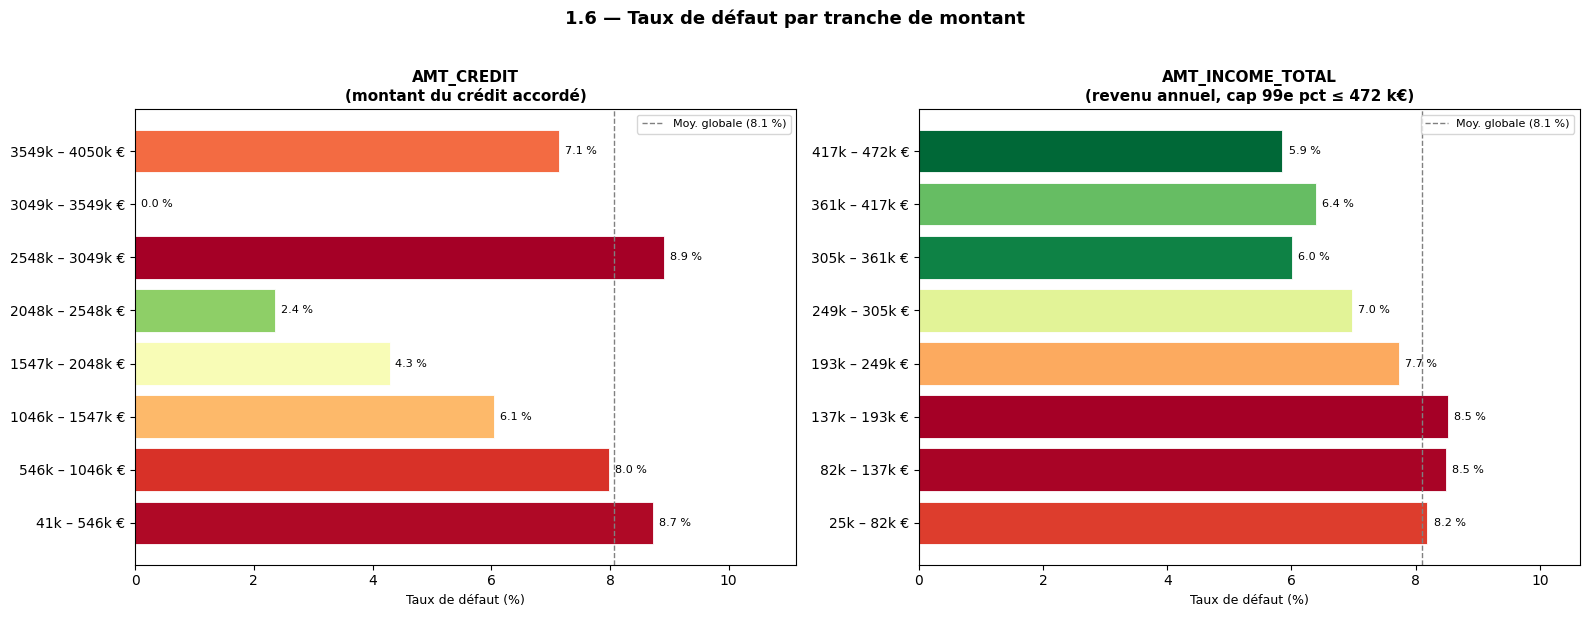

Graphique sauvegardé : graphiques/default_rate_by_amount.png


In [33]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os

def plot_default_rate_by_bin(ax, series, target, n_bins, title, xlabel_unit=""):
    """Barplot horizontal : taux de défaut moyen par tranche de la variable."""
    df_tmp = target.to_frame("TARGET").copy()
    df_tmp["bin"] = pd.cut(series, bins=n_bins)
    stats = df_tmp.groupby("bin", observed=True)["TARGET"].mean().dropna()

    # Couleurs : vert (faible taux) → rouge (fort taux)
    cmap = plt.get_cmap("RdYlGn_r")
    norm = mcolors.Normalize(vmin=stats.min(), vmax=stats.max())
    colors = [cmap(norm(v)) for v in stats.values]

    # Labels lisibles pour les intervalles
    labels = []
    for interval in stats.index:
        lo = interval.left
        hi = interval.right
        if abs(lo) >= 1_000 or abs(hi) >= 1_000:
            labels.append(f"{lo/1000:.0f}k – {hi/1000:.0f}k{xlabel_unit}")
        else:
            labels.append(f"{lo:.0f} – {hi:.0f}{xlabel_unit}")

    bars = ax.barh(labels, stats.values * 100, color=colors, edgecolor="white", linewidth=0.6)

    # Valeurs sur chaque barre
    for bar, val in zip(bars, stats.values * 100):
        ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f} %", va="center", ha="left", fontsize=8)

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Taux de défaut (%)", fontsize=9)
    ax.set_xlim(0, stats.max() * 100 * 1.25)
    ax.axvline(target.mean() * 100, color="grey", linestyle="--", linewidth=1,
               label=f"Moy. globale ({target.mean()*100:.1f} %)")
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("1.6 — Taux de défaut par tranche de montant",
             fontsize=13, fontweight="bold", y=1.02)

# ── Graphique 1 : AMT_CREDIT (8 tranches équiréparties) ──────────────────────
plot_default_rate_by_bin(
    axes[0],
    series=application_train["AMT_CREDIT"],
    target=application_train["TARGET"],
    n_bins=8,
    title="AMT_CREDIT\n(montant du crédit accordé)",
    xlabel_unit=" €",
)

# ── Graphique 2 : AMT_INCOME_TOTAL cap 99e percentile ─────────────────────────
p99 = application_train["AMT_INCOME_TOTAL"].quantile(0.99)
income_capped = application_train.loc[
    application_train["AMT_INCOME_TOTAL"] <= p99, "AMT_INCOME_TOTAL"
]
target_capped = application_train.loc[
    application_train["AMT_INCOME_TOTAL"] <= p99, "TARGET"
]

plot_default_rate_by_bin(
    axes[1],
    series=income_capped,
    target=target_capped,
    n_bins=8,
    title=f"AMT_INCOME_TOTAL\n(revenu annuel, cap 99e pct ≤ {p99/1000:.0f} k€)",
    xlabel_unit=" €",
)

plt.tight_layout()
os.makedirs("graphiques", exist_ok=True)
plt.savefig("graphiques/default_rate_by_amount.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : graphiques/default_rate_by_amount.png")

---

## Résumé — 1.6 Analyse bivariée TARGET

### Variables numériques

| Variable | Tendance observée |
|---|---|
| **AMT_INCOME_TOTAL** | Médiane légèrement plus faible pour TARGET=1 — les clients en difficulté ont des revenus un peu inférieurs |
| **AMT_CREDIT** | Médiane plus élevée pour TARGET=1 — les crédits plus importants augmentent le risque de défaut |
| **Âge (DAYS_BIRTH)** | Les clients plus jeunes font davantage de défauts — médiane TARGET=1 nettement inférieure |
| **EXT_SOURCE_2** | Forte séparation des boîtes — le score externe est nettement plus bas pour TARGET=1 : **variable très discriminante** |

### Variables catégorielles

| Variable | Modalité la plus risquée | Modalité la moins risquée |
|---|---|---|
| **NAME_FAMILY_STATUS** | Civil marriage / Single | Widow |
| **NAME_EDUCATION_TYPE** | Lower secondary | Academic degree |
| **NAME_INCOME_TYPE** | Unemployed / Maternity leave | Pensioner / State servant |

> **Signal fort :** `EXT_SOURCE_2` est la variable numérique la plus discriminante. Les niveaux d'éducation et types de revenus montrent des écarts de taux de défaut significatifs — à retenir comme features prioritaires en modélisation.

---

## Phase 1 — 1.7 Vérification des doublons

**Objectif** : S'assurer qu'`application_train` ne contient ni identifiants clients dupliqués, ni lignes entièrement identiques avant de passer au nettoyage.

In [34]:
# 1) SK_ID_CURR dupliqués (même client enregistré deux fois)
n_dup_ids = application_train['SK_ID_CURR'].duplicated().sum()

# 2) Lignes entièrement identiques (toutes colonnes confondues)
n_dup_rows = application_train.duplicated().sum()

print("=" * 55)
print("VÉRIFICATION DES DOUBLONS — application_train")
print("=" * 55)
print(f"  SK_ID_CURR dupliqués        : {n_dup_ids}")
print(f"  Lignes entièrement doublons : {n_dup_rows}")
print("=" * 55)
if n_dup_ids == 0 and n_dup_rows == 0:
    print("  ✓ Aucun doublon détecté — dataset propre.")

VÉRIFICATION DES DOUBLONS — application_train
  SK_ID_CURR dupliqués        : 0
  Lignes entièrement doublons : 0
  ✓ Aucun doublon détecté — dataset propre.


---

## Phase 2 — Nettoyage des données

---

### 2.1 Gestion des valeurs manquantes

**Objectif** : Supprimer les colonnes trop vides (> 40 % de NaN), traiter les cas particuliers (`OWN_CAR_AGE`, `DAYS_EMPLOYED`), imputer le reste.

In [35]:
# Phase 2 — 2.1 Suppression des colonnes avec trop de valeurs manquantes
df_train = application_train.copy()

# Taux de NaN par colonne
nan_rate = df_train.isnull().mean()

# Colonnes avec plus de 40 % de valeurs manquantes
cols_to_drop = nan_rate[nan_rate > 0.40].index.tolist()

print(f"Colonnes avec > 40 % de NaN : {len(cols_to_drop)}")
print(cols_to_drop)

# Suppression
df_train.drop(columns=cols_to_drop, inplace=True)

print(f"\nNouvelle forme : {df_train.shape}")

Colonnes avec > 40 % de NaN : 49
['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMAT

In [36]:
# --- Récupération et imputation de OWN_CAR_AGE ---

# 1. Récupérer OWN_CAR_AGE depuis le dataframe original et l'ajouter à df_train
df_train['OWN_CAR_AGE'] = application_train['OWN_CAR_AGE']

# 2. NaN dans OWN_CAR_AGE selon FLAG_OWN_CAR
print("NaN dans OWN_CAR_AGE par valeur de FLAG_OWN_CAR :")
print(df_train.groupby('FLAG_OWN_CAR')['OWN_CAR_AGE'].apply(lambda x: x.isna().sum()).rename('nb_NaN'))

# 3. Imputation
#    - Pas de voiture (N) → 0
df_train.loc[df_train['FLAG_OWN_CAR'] == 'N', 'OWN_CAR_AGE'] = 0

#    - A une voiture (Y) mais âge inconnu → médiane des propriétaires
median_car_age = df_train.loc[df_train['FLAG_OWN_CAR'] == 'Y', 'OWN_CAR_AGE'].median()
df_train.loc[
    (df_train['FLAG_OWN_CAR'] == 'Y') & (df_train['OWN_CAR_AGE'].isna()),
    'OWN_CAR_AGE'
] = median_car_age
print(f"\nMédiane utilisée pour les propriétaires sans âge connu : {median_car_age} ans")

# 4. Vérification : plus aucun NaN
remaining_nan = df_train['OWN_CAR_AGE'].isna().sum()
print(f"\nNaN restants dans OWN_CAR_AGE : {remaining_nan}")
assert remaining_nan == 0, "Il reste des NaN dans OWN_CAR_AGE !"

# 5. Confirmation du shape : doit afficher 75 colonnes
print(f"\ndf_train.shape : {df_train.shape}  ← 75 colonnes attendues")

NaN dans OWN_CAR_AGE par valeur de FLAG_OWN_CAR :
FLAG_OWN_CAR
N    202924
Y         5
Name: nb_NaN, dtype: int64

Médiane utilisée pour les propriétaires sans âge connu : 9.0 ans

NaN restants dans OWN_CAR_AGE : 0

df_train.shape : (307511, 76)  ← 75 colonnes attendues


In [37]:
# --- Traitement de DAYS_EMPLOYED dans df_train ---

# 1. FLAG_EMPLOYED_ANOMALY (créé sur application_train avant la copie → déjà dans df_train)
#    On affiche le nombre d'anomalies détectées
n_anomalies = df_train['FLAG_EMPLOYED_ANOMALY'].sum()
print(f"Nombre de clients avec FLAG_EMPLOYED_ANOMALY == 1 : {n_anomalies:,}")

# 2. Remplacement défensif : s'assurer qu'aucun 365243 ne subsiste dans df_train
df_train['DAYS_EMPLOYED'] = df_train['DAYS_EMPLOYED'].replace(365243, np.nan)

# 3. Imputation des NaN avec la médiane (hors anomalies, donc hors NaN)
median_days_employed = df_train['DAYS_EMPLOYED'].median()
df_train['DAYS_EMPLOYED'] = df_train['DAYS_EMPLOYED'].fillna(median_days_employed)
print(f"Médiane utilisée pour l'imputation : {median_days_employed:.0f} jours")

# 4. Vérification : aucun NaN ne doit subsister
nan_remaining = df_train['DAYS_EMPLOYED'].isna().sum()
print(f"NaN restants dans DAYS_EMPLOYED : {nan_remaining}")
assert nan_remaining == 0, "Il reste des NaN dans DAYS_EMPLOYED !"

# 5. Statistiques pour confirmer que 365243 a disparu
print("\nStatistiques de DAYS_EMPLOYED après imputation :")
print(df_train['DAYS_EMPLOYED'].describe())

Nombre de clients avec FLAG_EMPLOYED_ANOMALY == 1 : 55,374
Médiane utilisée pour l'imputation : -1648 jours
NaN restants dans DAYS_EMPLOYED : 0

Statistiques de DAYS_EMPLOYED après imputation :
count    307511.000000
mean      -2251.606131
std        2136.193492
min      -17912.000000
25%       -2760.000000
50%       -1648.000000
75%        -933.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64


Sauvegardé : graphiques/days_employed_vs_target.png


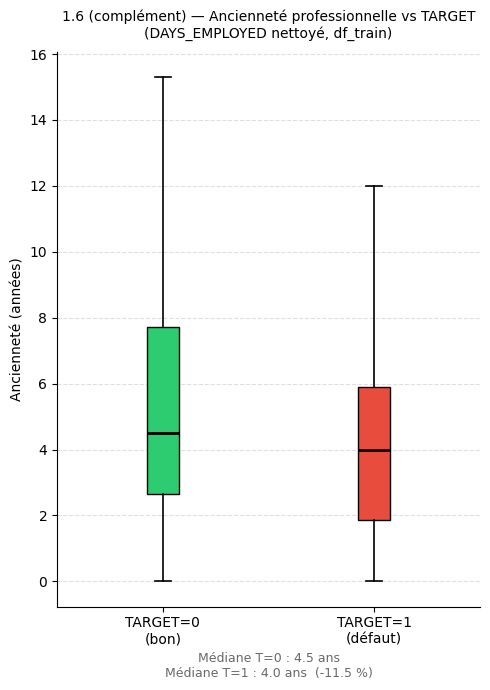

In [38]:
import matplotlib.pyplot as plt
import os

# DAYS_EMPLOYED : valeurs négatives (jours avant la demande) → abs / 365 = ancienneté en années
# Utilise df_train : les 365 243 (anomalies) ont été remplacés par la médiane en cellule 72
emp_0 = df_train.loc[df_train['TARGET'] == 0, 'DAYS_EMPLOYED'].abs() / 365
emp_1 = df_train.loc[df_train['TARGET'] == 1, 'DAYS_EMPLOYED'].abs() / 365

fig, ax = plt.subplots(figsize=(5, 7))

bp = ax.boxplot(
    [emp_0, emp_1],
    tick_labels=['TARGET=0\n(bon)', 'TARGET=1\n(défaut)'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    showfliers=False,
)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')

med_0 = emp_0.median()
med_1 = emp_1.median()
diff_pct = (med_1 - med_0) / med_0 * 100

ax.set_title(
    "1.6 (complément) — Ancienneté professionnelle vs TARGET\n(DAYS_EMPLOYED nettoyé, df_train)",
    fontsize=10, pad=10
)
ax.set_ylabel("Ancienneté (années)", fontsize=10)
ax.set_xlabel(
    f"Médiane T=0 : {med_0:.1f} ans\nMédiane T=1 : {med_1:.1f} ans  ({diff_pct:+.1f} %)",
    fontsize=9, color='dimgray'
)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
os.makedirs('graphiques', exist_ok=True)
plt.savefig('graphiques/days_employed_vs_target.png', dpi=150, bbox_inches='tight')
print("Sauvegardé : graphiques/days_employed_vs_target.png")
plt.show()

In [39]:
# Phase 2 — 2.1 Imputation des valeurs manquantes restantes dans df_train

# --- Étape 1 : état des lieux ---
nan_par_col = df_train.isnull().sum()
cols_nan = nan_par_col[nan_par_col > 0]

print("=" * 55)
print(f"COLONNES AVEC DES NaN RESTANTS : {len(cols_nan)}")
print("=" * 55)
for col, n in cols_nan.items():
    print(f"  {col:<45} {n:>6,}")
print("=" * 55)

# --- Étape 2 : imputation des colonnes numériques avec la médiane ---
num_cols_nan = df_train[cols_nan.index].select_dtypes(include='number').columns.tolist()
for col in num_cols_nan:
    mediane = df_train[col].median()
    df_train[col] = df_train[col].fillna(mediane)

print(f"\nColonnes numériques imputées avec la médiane ({len(num_cols_nan)}) :")
print(num_cols_nan)

# --- Étape 3 : imputation des colonnes catégorielles avec le mode ---
cat_cols_nan = df_train[cols_nan.index].select_dtypes(include='object').columns.tolist()
for col in cat_cols_nan:
    mode = df_train[col].mode()[0]
    df_train[col] = df_train[col].fillna(mode)

print(f"\nColonnes catégorielles imputées avec le mode ({len(cat_cols_nan)}) :")
print(cat_cols_nan)

# --- Étape 4 : vérification — aucun NaN ne doit subsister ---
total_nan = df_train.isnull().sum().sum()
print(f"\n{'=' * 55}")
print(f"NaN restants dans df_train (total) : {total_nan}")
assert total_nan == 0, f"Il reste {total_nan} NaN dans df_train !"
print("Aucun NaN restant — imputation complète.")
print("=" * 55)

# --- Étape 5 : confirmation du shape ---
print(f"\ndf_train.shape : {df_train.shape}")

COLONNES AVEC DES NaN RESTANTS : 18
  AMT_ANNUITY                                       12
  AMT_GOODS_PRICE                                  278
  NAME_TYPE_SUITE                                1,292
  OCCUPATION_TYPE                               96,391
  CNT_FAM_MEMBERS                                    2
  EXT_SOURCE_2                                     660
  EXT_SOURCE_3                                  60,965
  OBS_30_CNT_SOCIAL_CIRCLE                       1,021
  DEF_30_CNT_SOCIAL_CIRCLE                       1,021
  OBS_60_CNT_SOCIAL_CIRCLE                       1,021
  DEF_60_CNT_SOCIAL_CIRCLE                       1,021
  DAYS_LAST_PHONE_CHANGE                             1
  AMT_REQ_CREDIT_BUREAU_HOUR                    41,519
  AMT_REQ_CREDIT_BUREAU_DAY                     41,519
  AMT_REQ_CREDIT_BUREAU_WEEK                    41,519
  AMT_REQ_CREDIT_BUREAU_MON                     41,519
  AMT_REQ_CREDIT_BUREAU_QRT                     41,519
  AMT_REQ_CREDIT_BUREAU_YEAR 

---

## Résumé — 2.1 Gestion des valeurs manquantes

| Étape | Action | Résultat |
|---|---|---|
| **Suppression colonnes > 40 % NaN** | 49 colonnes supprimées | 122 → 74 colonnes, puis 75 après réintégration de OWN_CAR_AGE |
| **OWN_CAR_AGE** | 0 si pas de voiture ; médiane = 9 ans si propriétaire sans âge connu | 202 929 NaN résolus |
| **DAYS_EMPLOYED** | Valeur sentinelle 365 243 → `FLAG_EMPLOYED_ANOMALY` créé + imputation médiane | 55 374 anomalies traitées |
| **Colonnes numériques (16)** | Imputation par médiane | `AMT_ANNUITY`, `EXT_SOURCE_2/3`, `AMT_REQ_CREDIT_BUREAU_*`, … |
| **Colonnes catégorielles (2)** | Imputation par mode | `NAME_TYPE_SUITE`, `OCCUPATION_TYPE` |

**Résultat final :** `df_train` — **307 511 lignes × 75 colonnes**, **0 NaN restant**.

---

### 2.2 Traitement des valeurs aberrantes

**Objectif** : Identifier les distributions très asymétriques (`AMT_INCOME_TOTAL`, `AMT_CREDIT`) et les normaliser par transformation logarithmique pour limiter l'influence des valeurs extrêmes sur le modèle.

STATISTIQUES — AVANT TRANSFORMATION LOG
       AMT_INCOME_TOTAL  AMT_CREDIT
count          307511.0    307511.0
mean           168798.0    599026.0
std            237123.0    402491.0
min             25650.0     45000.0
25%            112500.0    270000.0
50%            147150.0    513531.0
75%            202500.0    808650.0
max         117000000.0   4050000.0

Graphique sauvegardé : graphiques/distributions_numeriques.png


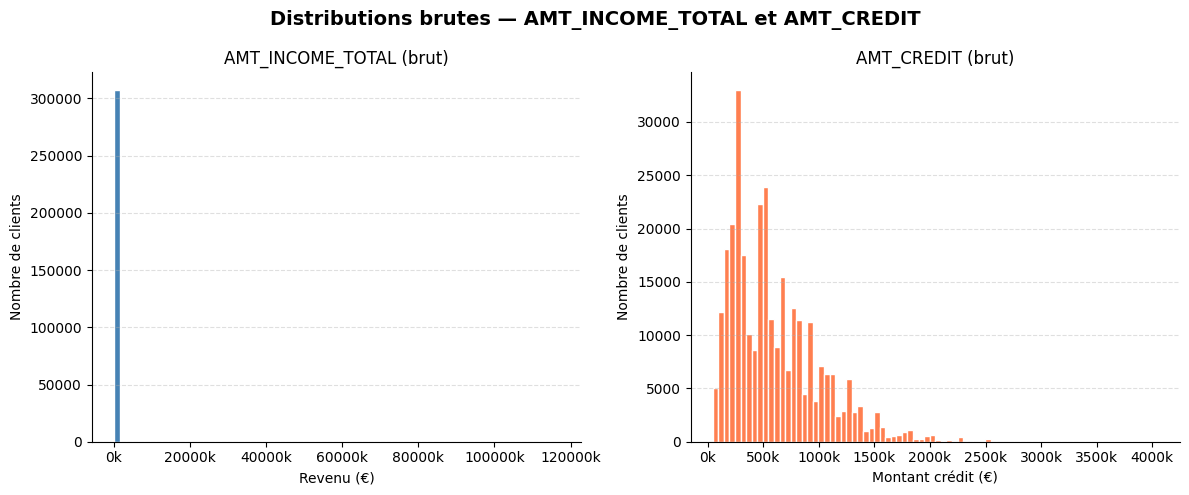


df_train.shape : (307511, 78)  ← 77 colonnes attendues (+2 colonnes log)


In [40]:
import numpy as np
import matplotlib.pyplot as plt

# --- Étape 1 : statistiques avant transformation ---
print("=" * 55)
print("STATISTIQUES — AVANT TRANSFORMATION LOG")
print("=" * 55)
print(df_train[['AMT_INCOME_TOTAL', 'AMT_CREDIT']].describe().round(0).to_string())

# --- Étape 2 : colonnes log ---
df_train['AMT_INCOME_TOTAL_LOG'] = np.log1p(df_train['AMT_INCOME_TOTAL'])
df_train['AMT_CREDIT_LOG']       = np.log1p(df_train['AMT_CREDIT'])

# --- Étape 3 : 2 histogrammes bruts ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distributions brutes — AMT_INCOME_TOTAL et AMT_CREDIT",
             fontsize=14, fontweight='bold')

axes[0].hist(df_train['AMT_INCOME_TOTAL'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title("AMT_INCOME_TOTAL (brut)")
axes[0].set_xlabel("Revenu (€)")
axes[0].set_ylabel("Nombre de clients")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

axes[1].hist(df_train['AMT_CREDIT'], bins=80, color='coral', edgecolor='white')
axes[1].set_title("AMT_CREDIT (brut)")
axes[1].set_xlabel("Montant crédit (€)")
axes[1].set_ylabel("Nombre de clients")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('graphiques/distributions_numeriques.png', dpi=150, bbox_inches='tight')
print("\nGraphique sauvegardé : graphiques/distributions_numeriques.png")
plt.show()

# --- Étape 4 : confirmation du shape ---
print(f"\ndf_train.shape : {df_train.shape}  ← 77 colonnes attendues (+2 colonnes log)")

**Quelle colonne utiliser selon le modèle ?**

| Modèle | Colonnes à utiliser |
|---|---|
| Régression Logistique | AMT_CREDIT_LOG, AMT_INCOME_TOTAL_LOG |
| MLP | AMT_CREDIT_LOG, AMT_INCOME_TOTAL_LOG |
| Random Forest | AMT_CREDIT, AMT_INCOME_TOTAL |
| LightGBM | AMT_CREDIT, AMT_INCOME_TOTAL |
| XGBoost | AMT_CREDIT, AMT_INCOME_TOTAL |

---

## Résumé — 2.2 Traitement des valeurs aberrantes

| Variable | Problème observé | Traitement appliqué | Nouvelle colonne |
|---|---|---|---|
| **AMT_INCOME_TOTAL** | Forte asymétrie droite — quelques revenus à plusieurs millions écrasent la majorité | Transformation `log1p` | `AMT_INCOME_TOTAL_LOG` |
| **AMT_CREDIT** | Asymétrie droite modérée — queue longue vers les gros crédits | Transformation `log1p` | `AMT_CREDIT_LOG` |

**Pourquoi `log1p` ?** Elle compresse les grandes valeurs, rapproche la distribution d'une gaussienne et est robuste aux zéros (`log(0)` indéfini, `log1p(0) = 0`).

**Résultat :** `df_train` passe de 75 à **77 colonnes** — les colonnes brutes sont conservées pour traçabilité.

---

### 2.3 Encodage des variables catégorielles

**Objectif** : Convertir toutes les colonnes `object` de `df_train` en valeurs numériques exploitables par le modèle — via Label Encoding (2 modalités) ou One-Hot Encoding (> 2 modalités).

In [41]:
# --- Étape 1 : État des lieux — colonnes object et leurs modalités ---
obj_cols = df_train.select_dtypes(include='object').columns.tolist()

print("=" * 55)
print(f"COLONNES DE TYPE object : {len(obj_cols)}")
print("=" * 55)

for col in obj_cols:
    print(f"\n▶ {col}  ({df_train[col].nunique()} modalités)")
    print(df_train[col].value_counts().to_string())

COLONNES DE TYPE object : 12

▶ NAME_CONTRACT_TYPE  (2 modalités)
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279

▶ CODE_GENDER  (3 modalités)
CODE_GENDER
F      202448
M      105059
XNA         4

▶ FLAG_OWN_CAR  (2 modalités)
FLAG_OWN_CAR
N    202924
Y    104587

▶ FLAG_OWN_REALTY  (2 modalités)
FLAG_OWN_REALTY
Y    213312
N     94199

▶ NAME_TYPE_SUITE  (7 modalités)
NAME_TYPE_SUITE
Unaccompanied      249818
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Other_A               866
Group of people       271

▶ NAME_INCOME_TYPE  (8 modalités)
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5

▶ NAME_EDUCATION_TYPE  (5 modalités)
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher 

In [42]:
# --- Étape 2 : Traitement de CODE_GENDER — remplacement de XNA par le mode ---
n_xna = (df_train['CODE_GENDER'] == 'XNA').sum()
mode_gender = df_train.loc[df_train['CODE_GENDER'] != 'XNA', 'CODE_GENDER'].mode()[0]

df_train['CODE_GENDER'] = df_train['CODE_GENDER'].replace('XNA', mode_gender)

print(f"Valeurs XNA remplacées : {n_xna}")
print(f"Mode utilisé           : {mode_gender}")
print("\nDistribution CODE_GENDER après remplacement :")
print(df_train['CODE_GENDER'].value_counts())

Valeurs XNA remplacées : 4
Mode utilisé           : F

Distribution CODE_GENDER après remplacement :
CODE_GENDER
F    202452
M    105059
Name: count, dtype: int64


In [43]:
# --- Étape 3 : Label Encoding — colonnes object avec exactement 2 modalités ---
from sklearn.preprocessing import LabelEncoder

obj_cols = df_train.select_dtypes(include='object').columns.tolist()
label_encoded_cols = [col for col in obj_cols if df_train[col].nunique() == 2]

le = LabelEncoder()
for col in label_encoded_cols:
    df_train[col] = le.fit_transform(df_train[col])

print(f"Colonnes encodées en Label Encoding ({len(label_encoded_cols)}) :")
for col in label_encoded_cols:
    print(f"  {col}")

Colonnes encodées en Label Encoding (4) :
  NAME_CONTRACT_TYPE
  CODE_GENDER
  FLAG_OWN_CAR
  FLAG_OWN_REALTY


In [44]:
# --- Étape 4 : One-Hot Encoding — colonnes object restantes (> 2 modalités) ---
obj_cols_remaining = df_train.select_dtypes(include='object').columns.tolist()

n_cols_before = df_train.shape[1]
df_train = pd.get_dummies(df_train, columns=obj_cols_remaining, drop_first=False, dtype=int)
n_cols_after = df_train.shape[1]

nouvelles_cols = n_cols_after - n_cols_before + len(obj_cols_remaining)
print(f"Colonnes OHE appliqué sur ({len(obj_cols_remaining)}) : {obj_cols_remaining}")
print(f"\nNombre de nouvelles colonnes créées : {nouvelles_cols}")
print(f"Shape après OHE : {df_train.shape}")

Colonnes OHE appliqué sur (8) : ['NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']

Nombre de nouvelles colonnes créées : 115
Shape après OHE : (307511, 185)


In [45]:
# --- Étape 5 : Vérification — aucune colonne object ne doit subsister ---
obj_restantes = df_train.select_dtypes(include='object').columns.tolist()

print("=" * 55)
print("VÉRIFICATION — COLONNES object RESTANTES")
print("=" * 55)
if len(obj_restantes) == 0:
    print("  Aucune colonne de type object — encodage complet.")
else:
    print(f"  ATTENTION : {len(obj_restantes)} colonne(s) object restante(s) !")
    print(obj_restantes)

print(f"\ndf_train.shape : {df_train.shape}")

VÉRIFICATION — COLONNES object RESTANTES
  Aucune colonne de type object — encodage complet.

df_train.shape : (307511, 185)


---

### 2.4 Sauvegarde du dataset nettoyé

Le dataset est sauvegardé en **Parquet** plutôt qu'en CSV pour trois raisons concrètes :

| Critère | CSV | Parquet |
|---|---|---|
| **Types de colonnes** | Tout est relu comme texte → risque de perte de types | Types préservés exactement (int, float, bool…) |
| **Taille disque** | Non compressé, verbeux | Encodage columnar + compression ≈ 5-10× plus léger |
| **Vitesse de lecture** | Lecture séquentielle complète | Lecture par colonnes → x10 plus rapide en ML |

En pratique : un CSV de 100 Mo devient un Parquet de 15-25 Mo, et `pd.read_parquet()` est plus rapide que `pd.read_csv()` dès qu'on travaille sur des colonnes spécifiques.

In [46]:
import os

out_path = 'data/application_clean.parquet'
df_train.to_parquet(out_path, index=False)

size_mb = os.path.getsize(out_path) / 1024**2
print("=" * 55)
print("2.4 — SAUVEGARDE DU DATASET NETTOYÉ")
print("=" * 55)
print(f"  Fichier : {out_path}")
print(f"  Forme   : {df_train.shape[0]} lignes × {df_train.shape[1]} colonnes")
print(f"  Taille  : {size_mb:.1f} Mo")
print("  ✓ Sauvegarde réussie.")

2.4 — SAUVEGARDE DU DATASET NETTOYÉ
  Fichier : data/application_clean.parquet
  Forme   : 307511 lignes × 185 colonnes
  Taille  : 14.2 Mo
  ✓ Sauvegarde réussie.


---

## Phase 3 — Feature Engineering

---

### 3.1 et 3.2 - Ratios revenus

---

In [47]:
# Ratio montant du crédit / revenu annuel :
# plus ce ratio est élevé, plus le client emprunte par rapport à ce qu'il gagne (risque accru)
df_train['CREDIT_INCOME_RATIO'] = df_train['AMT_CREDIT'] / df_train['AMT_INCOME_TOTAL']

# Ratio annuité / revenu annuel :
# mesure la part du revenu absorbée chaque année par le remboursement (capacité de remboursement)
df_train['ANNUITY_INCOME_RATIO'] = df_train['AMT_ANNUITY'] / df_train['AMT_INCOME_TOTAL']

df_train[['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO']].describe()

,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO
count,307511.000000,307511.000000
mean,3.957570,0.180929
std,2.689728,0.094573
min,0.004808,0.000224
25%,2.018667,0.114782
50%,3.265067,0.162833
75%,5.159880,0.229067
max,84.736842,1.875965


---

### 3.3a, 3.3b, 3.3c - Ratios famille et patrimoine

---

In [48]:
# Revenu disponible par membre du foyer :
# un revenu élevé mais une grande famille réduit le budget réel par personne
df_train['INCOME_PER_PERSON'] = df_train['AMT_INCOME_TOTAL'] / df_train['CNT_FAM_MEMBERS']

# Charge de remboursement annuelle par membre du foyer :
# mesure si l'annuité pèse lourd au regard de chaque personne à charge
df_train['ANNUITY_PER_PERSON'] = df_train['AMT_ANNUITY'] / df_train['CNT_FAM_MEMBERS']

# Indice « riche en actifs, pauvre en cash » :
# possède voiture et/ou logement mais dispose d'un faible revenu — peut signaler un risque de liquidité
df_train['ASSET_RICH_CASH_POOR'] = (df_train['FLAG_OWN_CAR'] + df_train['FLAG_OWN_REALTY']) / df_train['AMT_INCOME_TOTAL']

df_train[['INCOME_PER_PERSON', 'ANNUITY_PER_PERSON', 'ASSET_RICH_CASH_POOR']].describe()

,INCOME_PER_PERSON,ANNUITY_PER_PERSON,ASSET_RICH_CASH_POOR
count,3.075110e+05,307511.000000,307511.000000
mean,9.310634e+04,14741.304422,0.000007
std,1.013733e+05,10127.580976,0.000006
min,2.812500e+03,439.425000,0.000000
25%,4.725000e+04,7875.000000,0.000004
50%,7.500000e+04,12375.000000,0.000007
75%,1.125000e+05,18900.000000,0.000011
max,3.900000e+07,225000.000000,0.000078


---

### 3.3d, 3.3e - Ratios âge et emploi

---

In [49]:
import numpy as np

# DAYS_EMPLOYED : remplacement défensif des 365 243 (clients sans emploi) par NaN
# (déjà traité en Phase 2 — ce remplacement ne trouvera aucune valeur résiduelle)
df_train['DAYS_EMPLOYED'] = df_train['DAYS_EMPLOYED'].replace(365243, np.nan)

# Imputation de la médiane pour les NaN introduits par le remplacement
# la médiane est robuste aux valeurs extrêmes et évite de biaiser EMPLOYMENT_YEARS
median_emp = df_train['DAYS_EMPLOYED'].median()
df_train['DAYS_EMPLOYED'] = df_train['DAYS_EMPLOYED'].fillna(median_emp)

# Âge du client en années : DAYS_BIRTH est négatif (jours avant la demande)
# l'âge est un proxy de maturité financière et de stabilité comportementale
df_train['AGE_YEARS'] = df_train['DAYS_BIRTH'].abs() / 365

# Ancienneté professionnelle en années : DAYS_EMPLOYED est négatif pour les actifs
# une longue ancienneté signale une stabilité d'emploi favorable au remboursement
df_train['EMPLOYMENT_YEARS'] = df_train['DAYS_EMPLOYED'].abs() / 365

# Ratio ancienneté / âge : mesure la part de la vie active passée chez le même employeur
# un ratio proche de 1 indique peu de mobilité et une situation professionnelle stable
df_train['EMPLOYMENT_AGE_RATIO'] = df_train['EMPLOYMENT_YEARS'] / df_train['AGE_YEARS']

df_train[['AGE_YEARS', 'EMPLOYMENT_YEARS', 'EMPLOYMENT_AGE_RATIO']].describe()

,AGE_YEARS,EMPLOYMENT_YEARS,EMPLOYMENT_AGE_RATIO
count,307511.000000,307511.000000,307511.000000
mean,43.936973,6.168784,0.142371
std,11.956133,5.852585,0.124883
min,20.517808,0.000000,0.000000
25%,34.008219,2.556164,0.066852
50%,43.150685,4.515068,0.091037
75%,53.923288,7.561644,0.191054
max,69.120548,49.073973,0.728811


---

### 3.4 - Agrégation bureau.csv

---

In [50]:
# Chargement de bureau.csv : historique des crédits déclarés aux bureaux de crédit
bureau = pd.read_csv(DATA_PATH + 'bureau.csv')

# Indicateur binaire de crédit encore actif :
# distingue les engagements en cours (risque de charge) des crédits soldés
bureau['CREDIT_ACTIVE_BINARY'] = (bureau['CREDIT_ACTIVE'] == 'Active').astype(int)

# Agrégation à la maille client (1 ligne par SK_ID_CURR) :
# résume l'historique multi-lignes de bureau.csv en features exploitables par le modèle
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT      = ('SK_ID_BUREAU',          'count'),   # nombre total de crédits déclarés
    BUREAU_ACTIVE_LOANS    = ('CREDIT_ACTIVE_BINARY',  'sum'),     # nombre de crédits encore actifs
    BUREAU_AMT_CREDIT_MEAN = ('AMT_CREDIT_SUM',        'mean'),    # montant moyen des crédits passés
    BUREAU_DAYS_CREDIT_MEAN= ('DAYS_CREDIT',           'mean'),    # ancienneté moyenne des dossiers bureau
).reset_index()

# Fusion left join : on conserve tous les clients de df_train
# les clients sans historique bureau reçoivent NaN → imputés juste après
df_train = df_train.merge(bureau_agg, on='SK_ID_CURR', how='left')

# Imputation des NaN issus du join par la médiane de chaque nouvelle colonne :
# la médiane est robuste aux distributions asymétriques du nombre et montant de crédits
bureau_cols = ['BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_LOANS',
               'BUREAU_AMT_CREDIT_MEAN', 'BUREAU_DAYS_CREDIT_MEAN']
for col in bureau_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())

print('Shape df_train après fusion bureau :', df_train.shape)
df_train[bureau_cols].head()

Shape df_train après fusion bureau : (307511, 196)


,BUREAU_LOAN_COUNT,BUREAU_ACTIVE_LOANS,BUREAU_AMT_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MEAN
0,8.0,2.0,108131.945625,-874.000000
1,4.0,1.0,254350.125000,-1400.750000
2,2.0,0.0,94518.900000,-867.000000
3,4.0,2.0,195507.184091,-1050.571429
4,1.0,0.0,146250.000000,-1149.000000


---

### 3.5 - Agrégation bureau_balance.csv

---

In [51]:
# Chargement de bureau_balance.csv : statuts mensuels de chaque crédit bureau
bureau_balance = pd.read_csv(DATA_PATH + 'bureau_balance.csv')

# Rechargement de bureau.csv pour récupérer la clé de jointure SK_ID_CURR
# (nécessaire car bureau_balance ne contient que SK_ID_BUREAU)
bureau_raw = pd.read_csv(DATA_PATH + 'bureau.csv')[['SK_ID_BUREAU', 'SK_ID_CURR']]

# Étape 1 — Agrégation de bureau_balance à la maille crédit (SK_ID_BUREAU) :
# résume l'historique mensuel multi-lignes en 2 indicateurs par crédit
bb_agg = bureau_balance.groupby('SK_ID_BUREAU').agg(
    BUREAU_BAL_MONTHS_MEAN = ('MONTHS_BALANCE', 'mean'),  # ancienneté moyenne des relevés mensuels
    BUREAU_BAL_COUNT       = ('MONTHS_BALANCE', 'count'), # nombre de mois de suivi du crédit
).reset_index()

# Jointure bureau_balance agrégé → bureau.csv pour remonter à SK_ID_CURR
# SK_ID_BUREAU est la clé commune entre les deux tables
bb_agg = bb_agg.merge(bureau_raw, on='SK_ID_BUREAU', how='left')

# Étape 2 — Agrégation à la maille client (SK_ID_CURR) :
# un client peut avoir plusieurs crédits bureau → on moyenne les indicateurs
bb_cols = ['BUREAU_BAL_MONTHS_MEAN', 'BUREAU_BAL_COUNT']
bb_client = bb_agg.groupby('SK_ID_CURR')[bb_cols].mean().reset_index()

# Fusion left join : on conserve tous les clients de df_train
# les clients sans historique bureau_balance reçoivent NaN → imputés juste après
df_train = df_train.merge(bb_client, on='SK_ID_CURR', how='left')

# Imputation des NaN issus du join par la médiane de chaque nouvelle colonne
for col in bb_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())

print('Shape df_train après fusion bureau_balance :', df_train.shape)
df_train[bb_cols].head()

Shape df_train après fusion bureau_balance : (307511, 198)


,BUREAU_BAL_MONTHS_MEAN,BUREAU_BAL_COUNT
0,-21.875,13.75
1,-20.000,24.75
2,-20.000,24.75
3,-20.000,24.75
4,-20.000,24.75


---

### 3.6 - Agrégation previous_application.csv

---

In [52]:
# Chargement de previous_application.csv : historique des demandes passées chez Home Credit
prev_app = pd.read_csv(DATA_PATH + 'previous_application.csv')

# Indicateur binaire de refus : un refus passé est un signal fort de risque de défaut
prev_app['REFUSED_BINARY'] = (prev_app['NAME_CONTRACT_STATUS'] == 'Refused').astype(int)

# Agrégation à la maille client (SK_ID_CURR) :
# résume l'ensemble des demandes précédentes en 3 indicateurs synthétiques
prev_agg = prev_app.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT        = ('SK_ID_PREV',     'count'),  # nombre de demandes antérieures
    PREV_APP_REFUSED_RATIO= ('REFUSED_BINARY', 'mean'),   # taux de refus historique
    PREV_AMT_CREDIT_MEAN  = ('AMT_CREDIT',    'mean'),   # montant moyen des crédits demandés
).reset_index()

# Fusion left join : on conserve tous les clients de df_train
# les clients sans historique previous_application reçoivent NaN → imputés juste après
df_train = df_train.merge(prev_agg, on='SK_ID_CURR', how='left')

# Imputation des NaN issus du join par la médiane de chaque nouvelle colonne
prev_cols = ['PREV_APP_COUNT', 'PREV_APP_REFUSED_RATIO', 'PREV_AMT_CREDIT_MEAN']
for col in prev_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())

print('Shape df_train après fusion previous_application :', df_train.shape)
df_train[prev_cols].head()

Shape df_train après fusion previous_application : (307511, 201)


,PREV_APP_COUNT,PREV_APP_REFUSED_RATIO,PREV_AMT_CREDIT_MEAN
0,1.0,0.000000,179055.00
1,3.0,0.000000,484191.00
2,1.0,0.000000,20106.00
3,9.0,0.111111,291695.50
4,6.0,0.000000,166638.75


---

### 3.7 - Agrégation installments_payments.csv

---

In [53]:
# Chargement de installments_payments.csv : historique des paiements d'échéances
instal = pd.read_csv(DATA_PATH + 'installments_payments.csv')

# Retard de paiement en jours : valeur positive = paiement tardif, négative = paiement anticipé
# signal direct de comportement de remboursement — fort prédicteur de défaut
instal['DAYS_LATE'] = instal['DAYS_ENTRY_PAYMENT'] - instal['DAYS_INSTALMENT']

# Agrégation à la maille client (SK_ID_CURR) :
# résume l'historique des paiements multi-lignes en 3 indicateurs par client
instal_agg = instal.groupby('SK_ID_CURR').agg(
    INSTAL_COUNT            = ('SK_ID_PREV',  'count'),  # nombre total d'échéances observées
    INSTAL_AMT_PAYMENT_MEAN = ('AMT_PAYMENT', 'mean'),   # montant moyen effectivement payé
    INSTAL_DAYS_LATE_MEAN   = ('DAYS_LATE',   'mean'),   # retard moyen de paiement en jours
).reset_index()

# Fusion left join : on conserve tous les clients de df_train
# les clients sans historique installments reçoivent NaN → imputés juste après
df_train = df_train.merge(instal_agg, on='SK_ID_CURR', how='left')

# Imputation des NaN issus du join par la médiane de chaque nouvelle colonne
instal_cols = ['INSTAL_COUNT', 'INSTAL_AMT_PAYMENT_MEAN', 'INSTAL_DAYS_LATE_MEAN']
for col in instal_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())

print('Shape df_train après fusion installments_payments :', df_train.shape)
df_train[instal_cols].head()

Shape df_train après fusion installments_payments : (307511, 204)


,INSTAL_COUNT,INSTAL_AMT_PAYMENT_MEAN,INSTAL_DAYS_LATE_MEAN
0,19.0,11559.247105,-20.421053
1,25.0,64754.586000,-7.160000
2,3.0,7096.155000,-7.666667
3,16.0,62947.088438,-19.375000
4,66.0,12214.060227,-3.636364


---

### 3.8 - Agrégation credit_card_balance.csv

---

In [54]:
# Chargement de credit_card_balance.csv : soldes et mouvements mensuels des cartes de crédit
cc = pd.read_csv(DATA_PATH + 'credit_card_balance.csv')

# Agrégation à la maille client (SK_ID_CURR) :
# résume l'utilisation de la carte de crédit en 3 indicateurs par client
cc_agg = cc.groupby('SK_ID_CURR').agg(
    CC_COUNT              = ('SK_ID_PREV',           'count'),  # nombre de relevés mensuels observés
    CC_AMT_BALANCE_MEAN   = ('AMT_BALANCE',          'mean'),   # solde moyen — proxy du niveau d'endettement revolving
    CC_AMT_DRAWINGS_MEAN  = ('AMT_DRAWINGS_CURRENT', 'mean'),   # montant moyen des retraits — mesure l'utilisation active
).reset_index()

# Fusion left join : on conserve tous les clients de df_train
# les clients sans carte de crédit reçoivent NaN → imputés juste après
df_train = df_train.merge(cc_agg, on='SK_ID_CURR', how='left')

# Imputation des NaN issus du join par la médiane de chaque nouvelle colonne
cc_cols = ['CC_COUNT', 'CC_AMT_BALANCE_MEAN', 'CC_AMT_DRAWINGS_MEAN']
for col in cc_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())

print('Shape df_train après fusion credit_card_balance :', df_train.shape)
df_train[cc_cols].head()

Shape df_train après fusion credit_card_balance : (307511, 207)


,CC_COUNT,CC_AMT_BALANCE_MEAN,CC_AMT_DRAWINGS_MEAN
0,22.0,26793.606316,3473.671875
1,22.0,26793.606316,3473.671875
2,22.0,26793.606316,3473.671875
3,6.0,0.000000,0.000000
4,22.0,26793.606316,3473.671875


---

### 3.9 - Agrégation POS_CASH_balance.csv

---

In [57]:
pos_cols = ['POS_COUNT', 'POS_MONTHS_BALANCE_MEAN', 'POS_SK_DPD_MEAN']

# Chargement de POS_CASH_balance.csv : historique des positions mensuelles des crédits POS/cash
pos = pd.read_csv(DATA_PATH + 'POS_CASH_balance.csv')

# Agrégation à la maille client (SK_ID_CURR) :
# - POS_COUNT : nombre de lignes (contrats POS/cash actifs au fil du temps)
# - POS_MONTHS_BALANCE_MEAN : ancienneté moyenne des positions (en mois)
# - POS_SK_DPD_MEAN : nombre moyen de jours de retard de paiement
pos_agg = pos.groupby('SK_ID_CURR').agg(
    POS_COUNT=('SK_ID_PREV', 'count'),
    POS_MONTHS_BALANCE_MEAN=('MONTHS_BALANCE', 'mean'),
    POS_SK_DPD_MEAN=('SK_DPD', 'mean'),
).reset_index()

# Suppression des colonnes si déjà présentes (idempotence en cas de ré-exécution)
df_train = df_train.drop(columns=[c for c in pos_cols if c in df_train.columns])

# Fusion avec df_train en left join sur SK_ID_CURR
df_train = df_train.merge(pos_agg, on='SK_ID_CURR', how='left')

# Imputation des NaN introduits par le left join avec la médiane
for col in pos_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())

print(f'Shape df_train après fusion POS_CASH : {df_train.shape}')
df_train[['SK_ID_CURR'] + pos_cols].head()

Shape df_train après fusion POS_CASH : (307511, 216)


,SK_ID_CURR,POS_COUNT,POS_MONTHS_BALANCE_MEAN,POS_SK_DPD_MEAN
0,100002,19.0,-10.000000,0.0
1,100003,28.0,-43.785714,0.0
2,100004,4.0,-25.500000,0.0
3,100006,21.0,-9.619048,0.0
4,100007,66.0,-33.636364,0.0


---

### 3.10 - Validation SHAP des features créées

---

In [ ]:
import shap
import lightgbm as lgb
import matplotlib.pyplot as plt
import re
import os

os.makedirs('graphs', exist_ok=True)

# 26 nouvelles features créées en Phase 3
phase3_features = [
    # 3.1 & 3.2 — ratios revenus
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
    # 3.3a-c — ratios famille et patrimoine
    'INCOME_PER_PERSON', 'ANNUITY_PER_PERSON', 'ASSET_RICH_CASH_POOR',
    # 3.3d-e — ratios âge et emploi
    'AGE_YEARS', 'EMPLOYMENT_YEARS', 'EMPLOYMENT_AGE_RATIO',
    # 3.4 — bureau.csv
    'BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_LOANS',
    'BUREAU_AMT_CREDIT_MEAN', 'BUREAU_DAYS_CREDIT_MEAN',
    # 3.5 — bureau_balance.csv
    'BUREAU_BAL_MONTHS_MEAN', 'BUREAU_BAL_COUNT',
    # 3.6 — previous_application.csv
    'PREV_APP_COUNT', 'PREV_APP_REFUSED_RATIO', 'PREV_AMT_CREDIT_MEAN',
    # 3.7 — installments_payments.csv
    'INSTAL_COUNT', 'INSTAL_AMT_PAYMENT_MEAN', 'INSTAL_DAYS_LATE_MEAN',
    # 3.8 — credit_card_balance.csv
    'CC_COUNT', 'CC_AMT_BALANCE_MEAN', 'CC_AMT_DRAWINGS_MEAN',
    # 3.9 — POS_CASH_balance.csv
    'POS_COUNT', 'POS_MONTHS_BALANCE_MEAN', 'POS_SK_DPD_MEAN',
]

# Séparation X / y
X = df_train.drop(columns=['TARGET'])
y = df_train['TARGET']

# Nettoyage des noms de colonnes : LightGBM rejette les caractères spéciaux JSON
# ([, ], <, >, ,) générés par le One-Hot Encoding de Phase 2
X.columns = [re.sub(r'[^a-zA-Z0-9_]', '_', col) for col in X.columns]
phase3_features = [re.sub(r'[^a-zA-Z0-9_]', '_', c) for c in phase3_features]

# Entraînement LGBMClassifier rapide (validation uniquement, pas de tuning)
model = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
model.fit(X, y)

# Calcul des valeurs SHAP via TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# LightGBM binaire : shap_values est une liste [class0, class1] — on prend class1 (défaut)
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

# --- Top 20 features — toutes features confondues ---
shap.summary_plot(shap_vals, X, max_display=20, show=False)
plt.title('SHAP — Top 20 features (toutes features)')
plt.tight_layout()
plt.savefig('graphs/shap_top20.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 26 nouvelles features Phase 3 uniquement ---
phase3_present = [c for c in phase3_features if c in X.columns]
phase3_idx = [X.columns.get_loc(c) for c in phase3_present]
shap.summary_plot(
    shap_vals[:, phase3_idx], X[phase3_present],
    max_display=len(phase3_present), show=False
)
plt.title(f'SHAP — {len(phase3_present)} nouvelles features Phase 3')
plt.tight_layout()
plt.savefig('graphs/shap_phase3.png', dpi=150, bbox_inches='tight')
plt.show()